/usr/bin/python
LD_LIBRARY_PATH contains nvidia: False
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1775942059.272056     419 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775942059.289405     419 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775942059.291429     419 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


170498071/170498071 [==============================] - 12s 0us/step


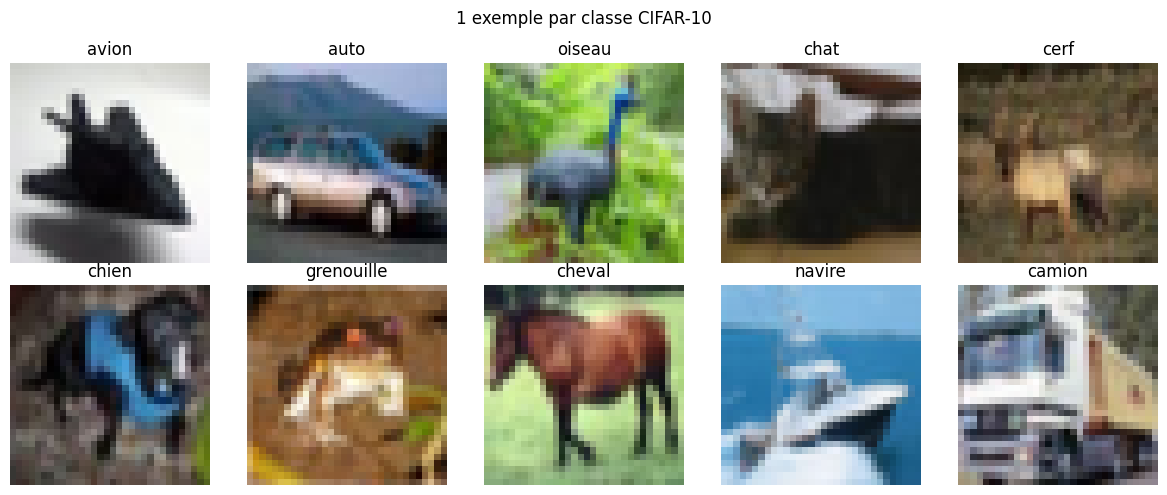

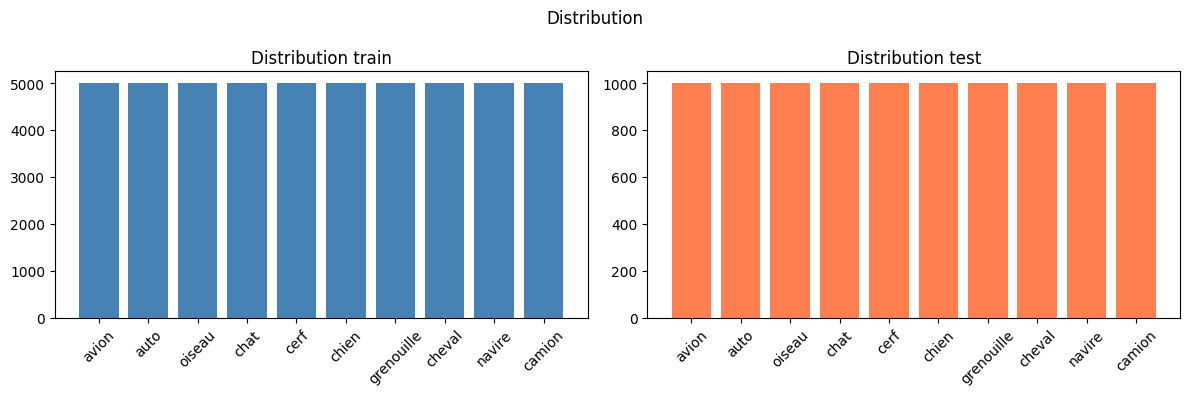

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1775942074.968616     419 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775942074.974532     419 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775942074.976640     419 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775942075.058733     419 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Shuffling /root/tensorflow_datasets/cifar10_1/v4/incomplete.16CSNT_1.1.0/cifar10_1-test.tfrecord*...:   0%|   …

Dataset cifar10_1 downloaded and prepared to /root/tensorflow_datasets/cifar10_1/v4/1.1.0. Subsequent calls will reuse this data.


In [1]:
import os
import sys
import gc
import numpy as np
import pandas as pd

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)    # suppress absl INFO/WARNING

import tensorflow as tf
tf.get_logger().setLevel('ERROR')                  # suppress TF Python-level logs

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow import keras
from tensorflow.keras import layers, applications

import tensorflow_datasets as tfds
from tensorflow_datasets.image_classification import cifar10_1

sys.path.insert(0, "Devoir partie 2/code")
from visualization import (
    image_sample_by_class,
    distribution,
    confusion_matrices,
    classification_error_samples,
    error_confidence,
    learning_curve
    )


print(sys.executable)
# sys.executable = "./scripts/tf_gpu_env.fish
print("LD_LIBRARY_PATH contains nvidia:", "site-packages/nvidia" in os.environ.get("LD_LIBRARY_PATH",""))

USE_GPU = True
CLASS_NAMES = ['avion','auto','oiseau','chat','cerf',
               'chien','grenouille','cheval','navire','camion']
               
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if gpus and USE_GPU:
    tf.config.set_visible_devices(gpus[0], "GPU")

    # Set memory growth If you want to use the local GPU IN case of desktop performance issues
    # tf.config.experimental.set_memory_growth(gpus[0], True)
    
else:
    print("No GPU detected by TensorFlow. CPU fallback.")


# Notebook  : Réseaux de Neurones Convolutionnels (CNN) pour la Classification d’Images
# Charger le dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation des images
x_train, x_test = x_train / 255.0, x_test / 255.0

# Exemples d'images CIFAR-10 par classe
image_sample_by_class(x_train, y_train)
# Distribution des classes (train + test)
distribution(y_train, y_test)

### CIFAR-10.1 pour validation externe

ds = tfds.load('cifar10_1', split='test', as_supervised=True)

x_ext = np.array([img.numpy() for img, _ in ds]) / 255.0
y_ext = np.array([lbl.numpy() for _, lbl in ds]).reshape(-1, 1)
# Le reshape(-1, 1) sur les labels est pour garder la même forme que y_test de CIFAR-10 (qui est (N, 1) avec sparse_categorical_crossentropy).


def benchmark_tracker(
    action="log",
    run_id=None,
    history=None,
    test_acc=None,
    test_loss=None,
    ext_acc=None,
    ext_loss=None,
    model_family=None,
    optimizer=None,
    augmentation=None,
    regularization=None,
    notes=None,
    sort_by=("ext_acc", "test_acc", "best_val_acc"),
    ascending=False,
):
    """
    action='log' : enregistre un run
    action='show': retourne le tableau comparatif complet (DataFrame)
    action='reset': vide l'historique
    """
    global _BENCHMARK_RUNS
    if "_BENCHMARK_RUNS" not in globals():
        _BENCHMARK_RUNS = []

    if action == "reset":
        _BENCHMARK_RUNS = []
        return None

    if action == "log":
        if run_id is None:
            raise ValueError("run_id est requis pour action='log'")

        row = {
            "run_id": run_id,
            "model_family": model_family,
            "optimizer": optimizer,
            "augmentation": augmentation,
            "regularization": regularization,
            "test_acc": test_acc,
            "test_loss": test_loss,
            "ext_acc": ext_acc,
            "ext_loss": ext_loss,
            "notes": notes,
        }

        if history is not None and hasattr(history, "history"):
            h = history.history
            train_acc_key = "accuracy" if "accuracy" in h else None
            val_acc_key = "val_accuracy" if "val_accuracy" in h else None
            train_loss_key = "loss" if "loss" in h else None
            val_loss_key = "val_loss" if "val_loss" in h else None
            lr_key = "learning_rate" if "learning_rate" in h else ("lr" if "lr" in h else None)

            if train_acc_key and val_acc_key and len(h[val_acc_key]) > 0:
                row["final_train_acc"] = float(h[train_acc_key][-1])
                row["final_val_acc"] = float(h[val_acc_key][-1])
                row["best_val_acc"] = float(np.max(h[val_acc_key]))
                row["best_val_acc_epoch"] = int(np.argmax(h[val_acc_key]) + 1)
                row["acc_gap_train_minus_val"] = row["final_train_acc"] - row["final_val_acc"]

            if train_loss_key and val_loss_key and len(h[val_loss_key]) > 0:
                row["final_train_loss"] = float(h[train_loss_key][-1])
                row["final_val_loss"] = float(h[val_loss_key][-1])
                row["best_val_loss"] = float(np.min(h[val_loss_key]))
                row["best_val_loss_epoch"] = int(np.argmin(h[val_loss_key]) + 1)

            if val_acc_key and len(h[val_acc_key]) > 0:
                row["epochs_ran"] = int(len(h[val_acc_key]))
            if lr_key and len(h[lr_key]) > 0:
                row["final_lr"] = float(h[lr_key][-1])

        if test_acc is not None and ext_acc is not None:
            row["generalization_drop_test_to_ext"] = float(test_acc) - float(ext_acc)

        _BENCHMARK_RUNS.append(row)
        return None

    if action == "show":
        if len(_BENCHMARK_RUNS) == 0:
            return pd.DataFrame()

        df = pd.DataFrame(_BENCHMARK_RUNS)

        preferred_cols = [
            "run_id", "model_family", "optimizer", "augmentation", "regularization",
            "test_acc", "ext_acc", "generalization_drop_test_to_ext",
            "best_val_acc", "final_train_acc", "final_val_acc",
            "acc_gap_train_minus_val", "epochs_ran", "final_lr",
            "test_loss", "ext_loss", "best_val_loss",
            "best_val_acc_epoch", "best_val_loss_epoch", "notes",
        ]
        cols = [c for c in preferred_cols if c in df.columns] + [c for c in df.columns if c not in preferred_cols]
        df = df[cols]

        valid_sort = [c for c in sort_by if c in df.columns]
        if valid_sort:
            df = df.sort_values(valid_sort, ascending=ascending)

        df = df.reset_index(drop=True)
        df.insert(0, "rank", np.arange(1, len(df) + 1))

        return df

    raise ValueError("action doit être 'log' ou 'show' ou 'reset'")


benchmark_tracker(action="reset")



58889256/58889256 [==============================] - 4s 0us/step
Epoch 1/100


W0000 00:00:1775942080.709327     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.715273     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.715438     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.716560     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.716739     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.716929     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.720515     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.720724     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942080.721071     570 gp

   2/1563 [..............................] - ETA: 1:59 - loss: 2.5645 - accuracy: 0.1094 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1775942081.170414     572 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target

  44/1563 [..............................] - ETA: 9s - loss: 2.1967 - accuracy: 0.1967 

...

1563/1563 [==============================] - ETA: 0s - loss: 1.3194 - accuracy: 0.5422

W0000 00:00:1775942087.349323     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349424     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349499     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349596     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349684     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349778     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349848     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.349947     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942087.350027     570 gp

1563/1563 [==============================] - 8s 5ms/step - loss: 1.3194 - accuracy: 0.5422 - val_loss: 1.0422 - val_accuracy: 0.6394 - lr: 0.0010
Epoch 2/100
  29/1563 [..............................] - ETA: 5s - loss: 1.1431 - accuracy: 0.5991

W0000 00:00:1775942088.662789     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.662889     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.662962     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.663052     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.663136     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.663225     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.663295     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.663391     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942088.663471     573 gp

1563/1563 [==============================] - 7s 5ms/step - loss: 1.0778 - accuracy: 0.6263 - val_loss: 0.9830 - val_accuracy: 0.6591 - lr: 0.0010
Epoch 3/100
1563/1563 [==============================] - 7s 5ms/step - loss: 1.0201 - accuracy: 0.6447 - val_loss: 0.9423 - val_accuracy: 0.6667 - lr: 0.0010
Epoch 4/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9846 - accuracy: 0.6568 - val_loss: 0.9141 - val_accuracy: 0.6770 - lr: 0.0010
Epoch 5/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9556 - accuracy: 0.6672 - val_loss: 0.9164 - val_accuracy: 0.6805 - lr: 0.0010
Epoch 6/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9380 - accuracy: 0.6736 - val_loss: 0.8938 - val_accuracy: 0.6869 - lr: 0.0010
Epoch 7/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9200 - accuracy: 0.6801 - val_loss: 0.8805 - val_accuracy: 0.6906 - lr: 0.0010
Epoch 8/100
1563/1563 [==============================] - 7s 5ms/

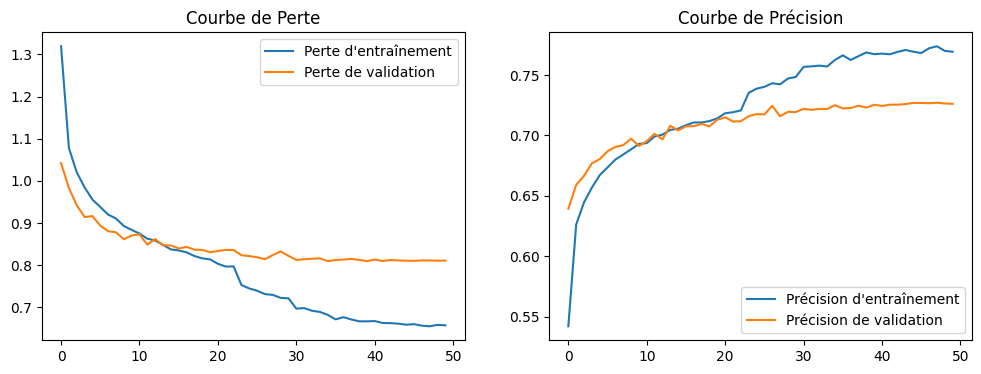

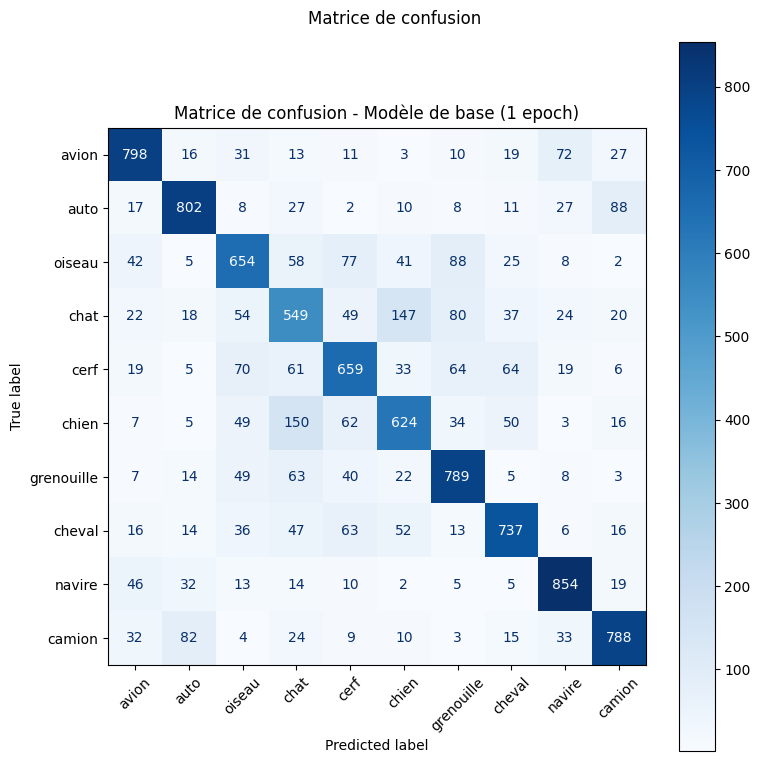

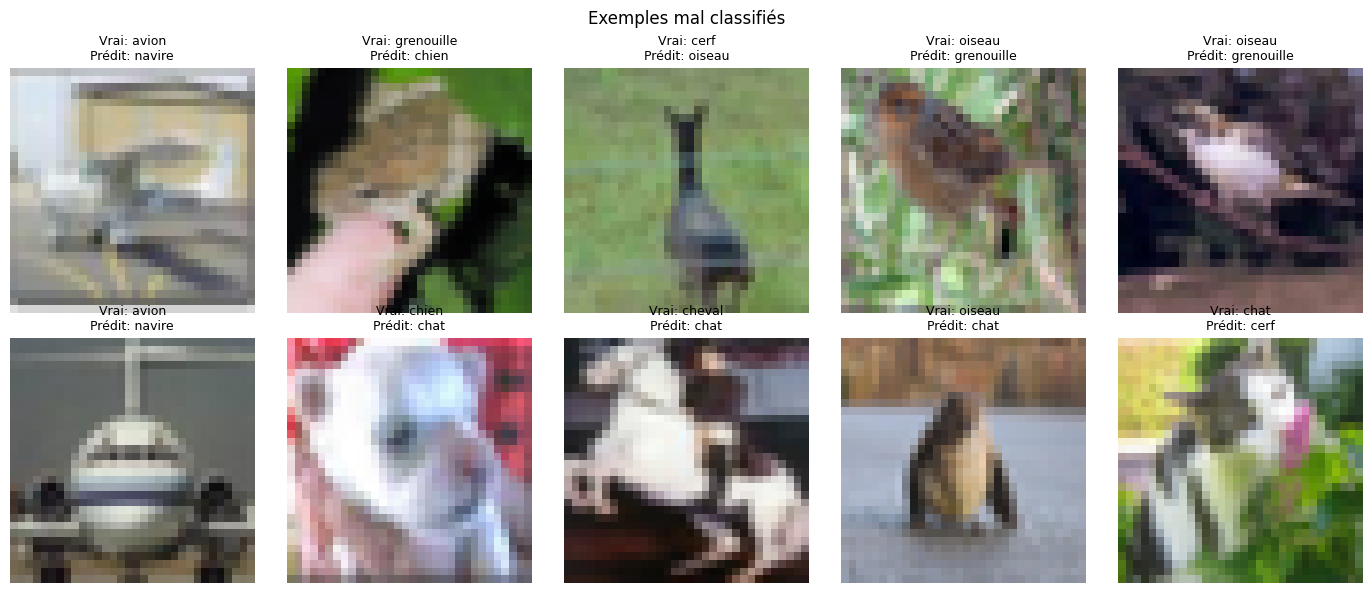

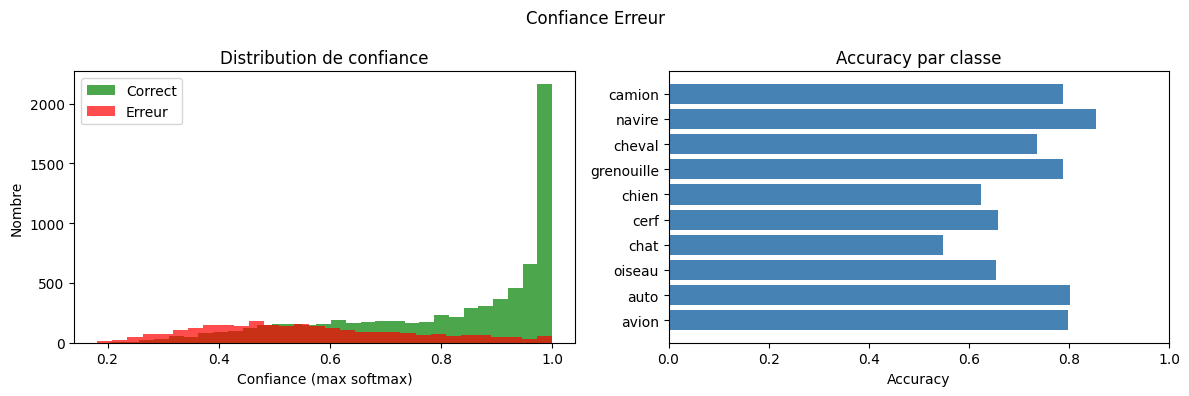

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.2840 - accuracy: 0.5938 - 324ms/epoch - 5ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.5938
34/64 [==============>...............] - ETA: 0s

W0000 00:00:1775942444.571287     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571350     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571386     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571434     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571478     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571522     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571564     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571613     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942444.571651     572 gp

64/64 [==============================] - 0s 3ms/step


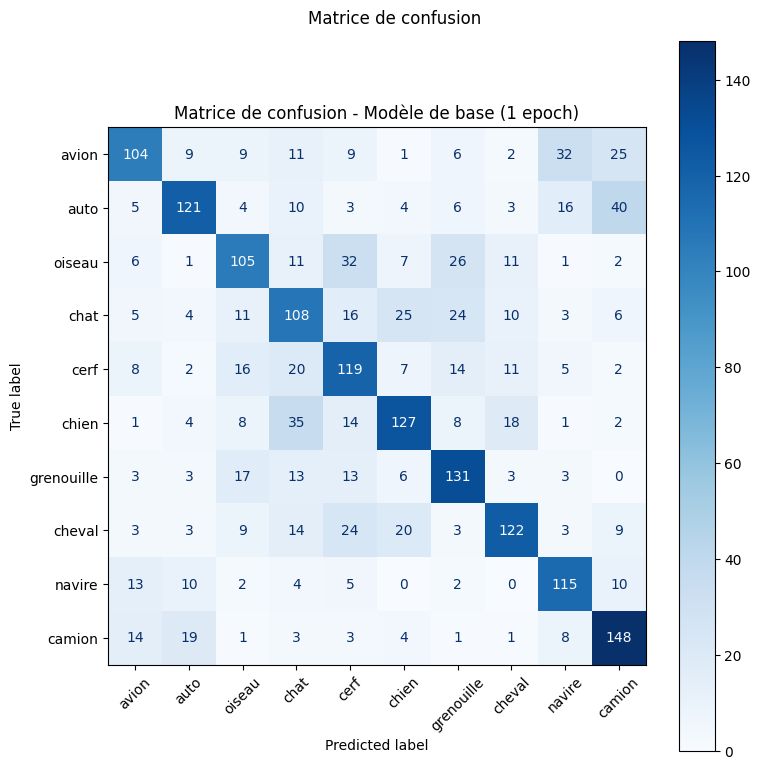

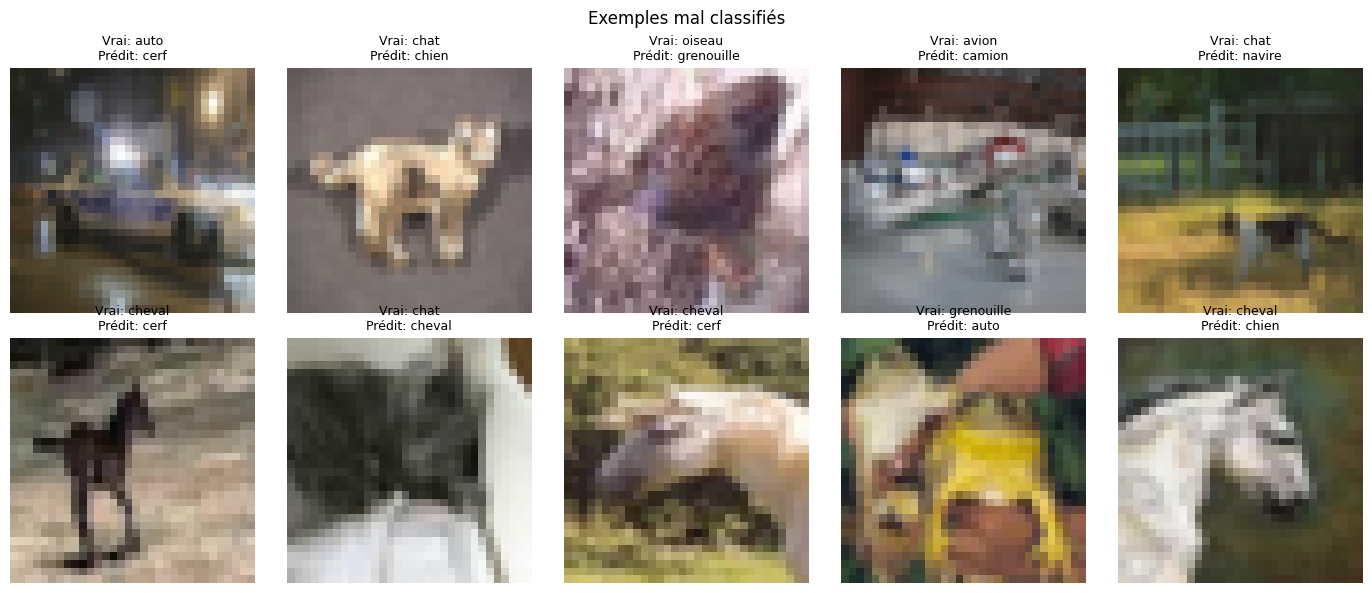

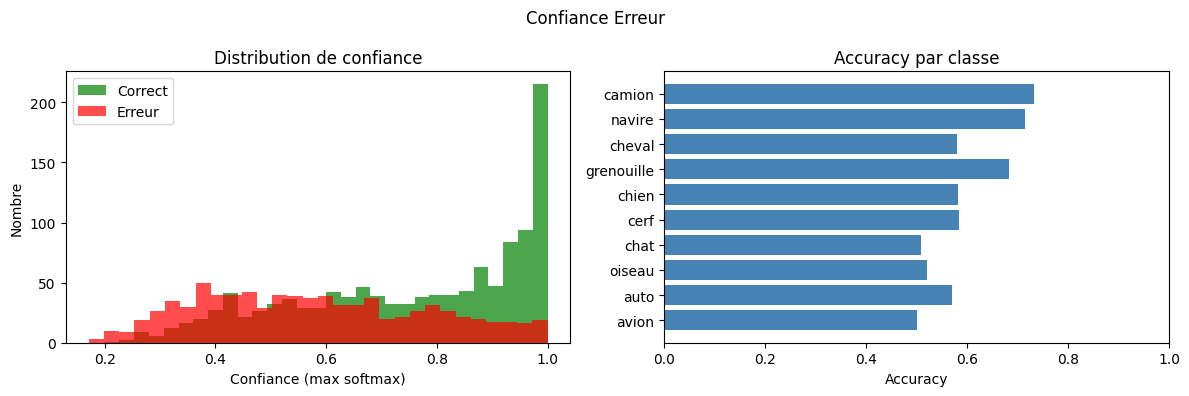

52950

In [2]:
# Question pour expérimenter l'Apprentissage par Transfert Avec quelques modifications

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(96, 96),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = transfer_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)
y_pred = transfer_model.predict(x_test).argmax(axis=1)
y_proba = transfer_model.predict(x_test)

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = transfer_model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = transfer_model.predict(x_ext).argmax(axis=1)
y_proba_ext = transfer_model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_01_transfer_vgg16_resize96",
    history=history_fit,
    test_acc=test_acc_transfer,
    test_loss=test_loss_transfer,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="Transfer Learning",
    optimizer="Adam",
    augmentation="resize96",
    regularization="EarlyStopping+ReduceLROnPlateau+Dropout",
    notes="VGG16 frozen + GAP"
)

del y_proba, y_pred, history_fit, transfer_model
gc.collect()

Epoch 1/100


W0000 00:00:1775942446.872646     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872709     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872735     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872767     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872794     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872823     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872865     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872905     574 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942446.872935     574 gp

  33/1563 [..............................] - ETA: 4s - loss: 2.2707 - accuracy: 0.1259 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775942447.095231     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942447.095311     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942447.095360     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942447.095710     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942447.095770     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942447.095824     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942447.095893     571 gpu_timer.cc:114] Skipping

1535/1563 [============================>.] - ETA: 0s - loss: 1.4834 - accuracy: 0.4573

...

1563/1563 [==============================] - 1s 947us/step - loss: 0.7550 - accuracy: 0.7340 - val_loss: 0.9140 - val_accuracy: 0.6921
Epoch 6/100
   1/1563 [..............................] - ETA: 2s - loss: 0.8989 - accuracy: 0.6250

W0000 00:00:1775942454.700285     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700335     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700369     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700402     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700431     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700464     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700501     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700545     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942454.700598     571 gp

1563/1563 [==============================] - 1s 946us/step - loss: 0.6861 - accuracy: 0.7591 - val_loss: 0.8446 - val_accuracy: 0.7122
Epoch 7/100
   1/1563 [..............................] - ETA: 1s - loss: 0.5520 - accuracy: 0.7500

W0000 00:00:1775942456.174985     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175034     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175067     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175097     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175131     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175163     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175196     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175242     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942456.175290     570 gp

1563/1563 [==============================] - 1s 936us/step - loss: 0.6296 - accuracy: 0.7793 - val_loss: 0.8295 - val_accuracy: 0.7223
Epoch 8/100
1563/1563 [==============================] - 1s 944us/step - loss: 0.5762 - accuracy: 0.7981 - val_loss: 0.8862 - val_accuracy: 0.7115
Epoch 9/100
1563/1563 [==============================] - 1s 926us/step - loss: 0.5293 - accuracy: 0.8140 - val_loss: 0.8892 - val_accuracy: 0.7134
Epoch 10/100
1563/1563 [==============================] - 1s 955us/step - loss: 0.4848 - accuracy: 0.8289 - val_loss: 0.8874 - val_accuracy: 0.7156
Epoch 11/100
1563/1563 [==============================] - 1s 927us/step - loss: 0.4420 - accuracy: 0.8440 - val_loss: 0.9357 - val_accuracy: 0.7168
Epoch 12/100
1563/1563 [==============================] - 1s 935us/step - loss: 0.4035 - accuracy: 0.8556 - val_loss: 0.9999 - val_accuracy: 0.7072
Epoch 13/100
1563/1563 [==============================] - 1s 931us/step - loss: 0.3732 - accuracy: 0.8690 - val_loss: 0.9909 - 

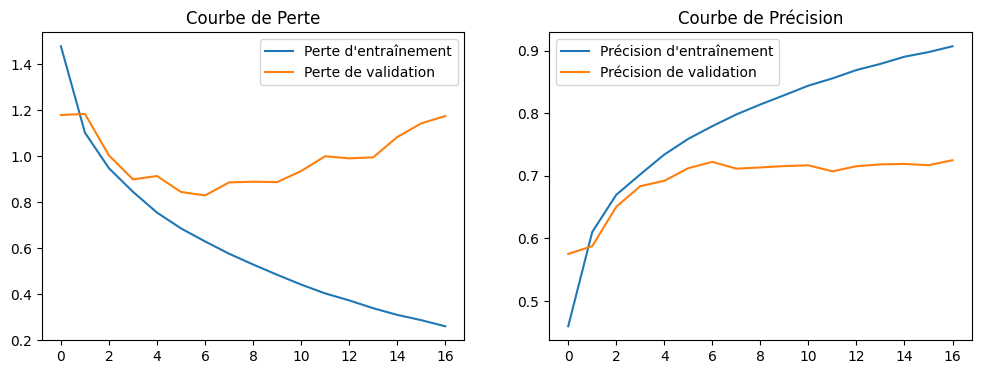

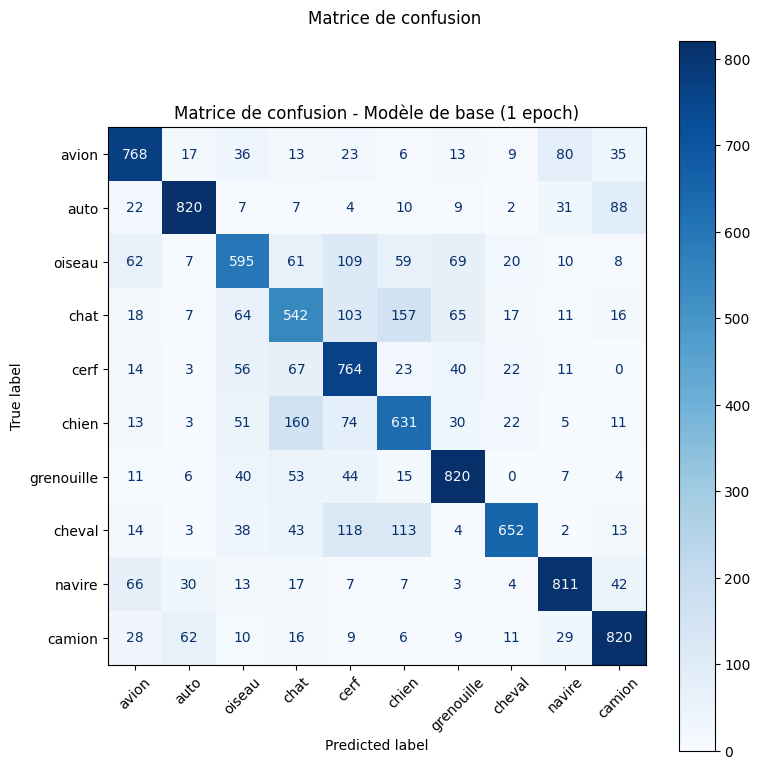

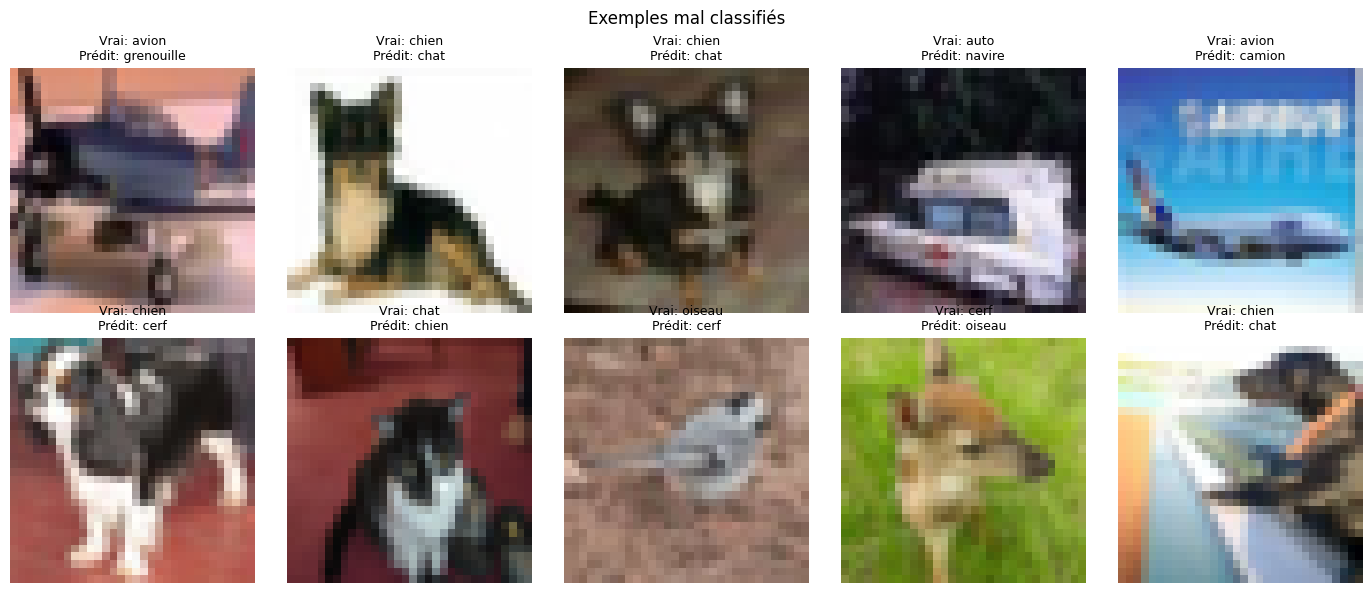

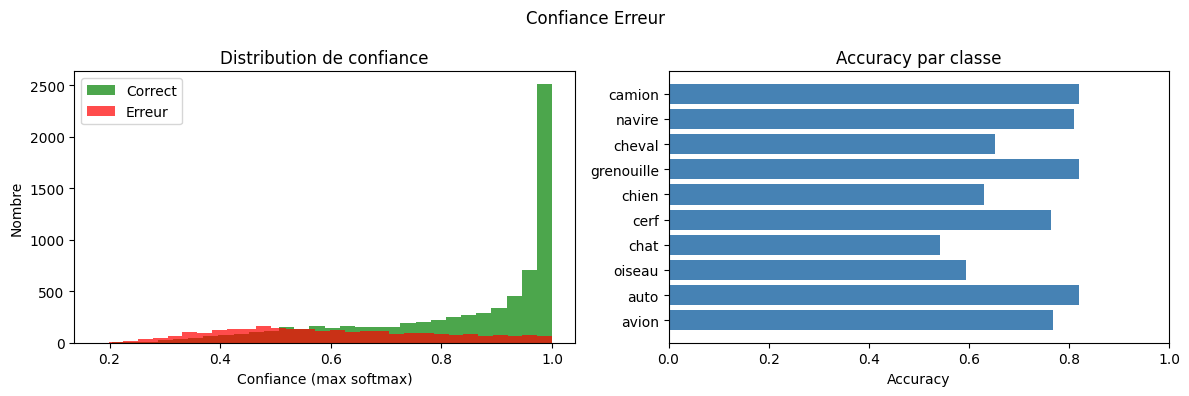

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.3517 - accuracy: 0.5844 - 81ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.5844
64/64 [==============================] - 0s 370us/step


W0000 00:00:1775942473.592937     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.592990     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593009     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593029     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593052     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593075     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593120     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593145     571 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942473.593172     571 gp

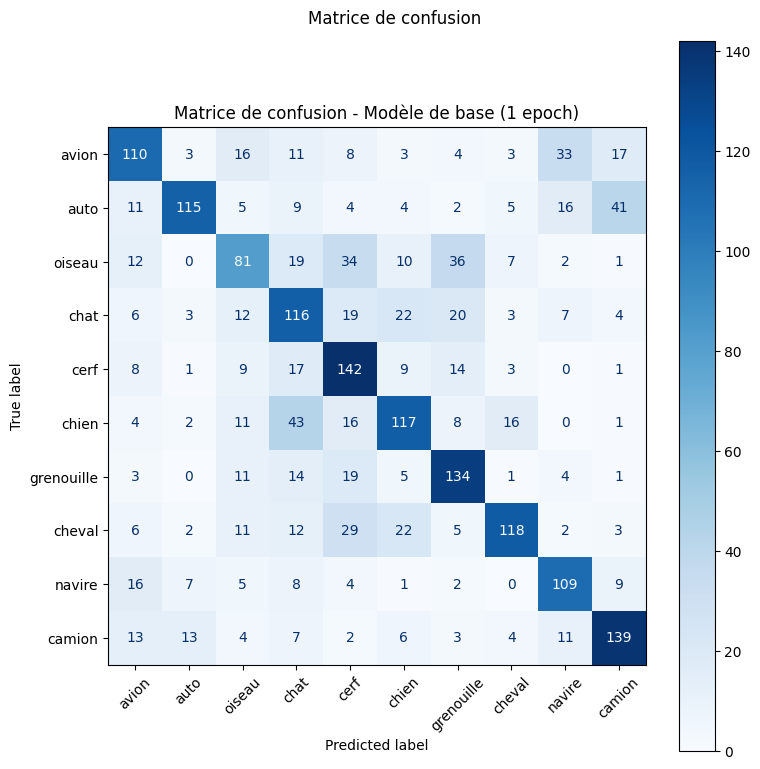

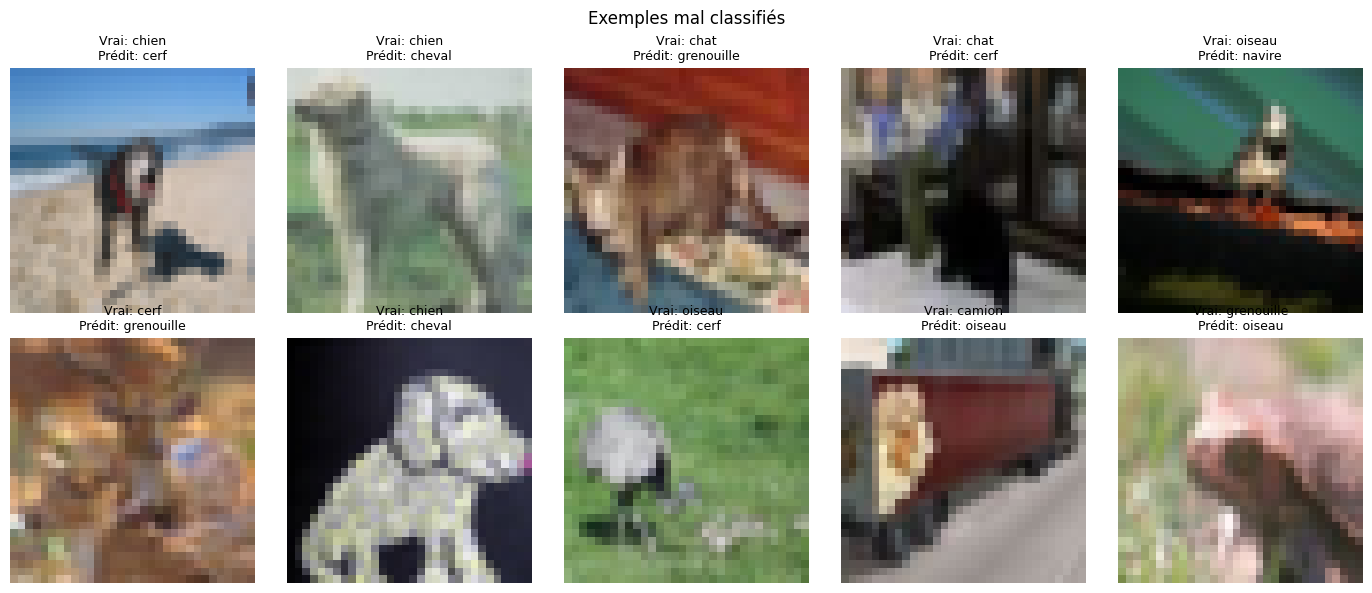

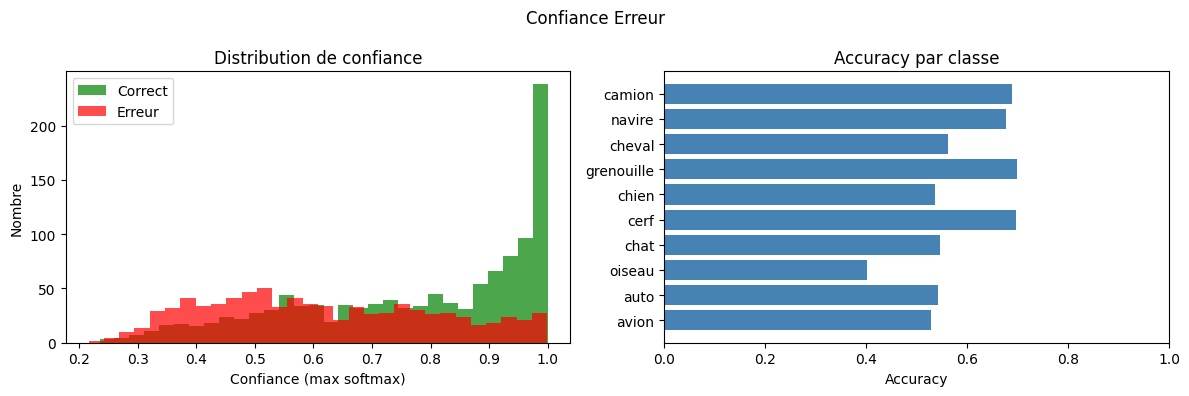

99609

In [3]:
# Définition du modèle CNN de base
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_02_cnn_base",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="Adam",
    augmentation="none",
    regularization="EarlyStopping",
    notes="Baseline"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

   1/1563 [..............................] - ETA: 17:38 - loss: 3.3328 - accuracy: 0.0938

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775942475.192861     564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942475.192949     564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942475.192987     564 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be 

1550/1563 [============================>.] - ETA: 0s - loss: 1.6790 - accuracy: 0.3868

W0000 00:00:1775942476.939674     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939739     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939774     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939805     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939846     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939880     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939927     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.939955     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942476.940032     566 gp

1563/1563 [==============================] - 3s 1ms/step - loss: 1.6776 - accuracy: 0.3873 - val_loss: 1.3601 - val_accuracy: 0.5087
Epoch 2/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.3520 - accuracy: 0.5173 - val_loss: 1.2344 - val_accuracy: 0.5690
Epoch 3/20
   1/1563 [..............................] - ETA: 2s - loss: 1.1063 - accuracy: 0.6250

W0000 00:00:1775942478.852948     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853012     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853048     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853078     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853119     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853155     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853201     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853229     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942478.853305     568 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 1.2283 - accuracy: 0.5672 - val_loss: 1.0865 - val_accuracy: 0.6190
Epoch 4/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1439 - accuracy: 0.6007 - val_loss: 1.0452 - val_accuracy: 0.6388
Epoch 5/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0839 - accuracy: 0.6248 - val_loss: 0.9133 - val_accuracy: 0.6856
Epoch 6/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0327 - accuracy: 0.6411 - val_loss: 1.1147 - val_accuracy: 0.6083
Epoch 7/20
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9909 - accuracy: 0.6591 - val_loss: 0.9013 - val_accuracy: 0.6905
Epoch 8/20
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9667 - accuracy: 0.6655 - val_loss: 0.8596 - val_accuracy: 0.7016
Epoch 9/20
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9371 - accuracy: 0.6780 - val_loss: 0.8574 - val_accuracy: 0.7029
Epo

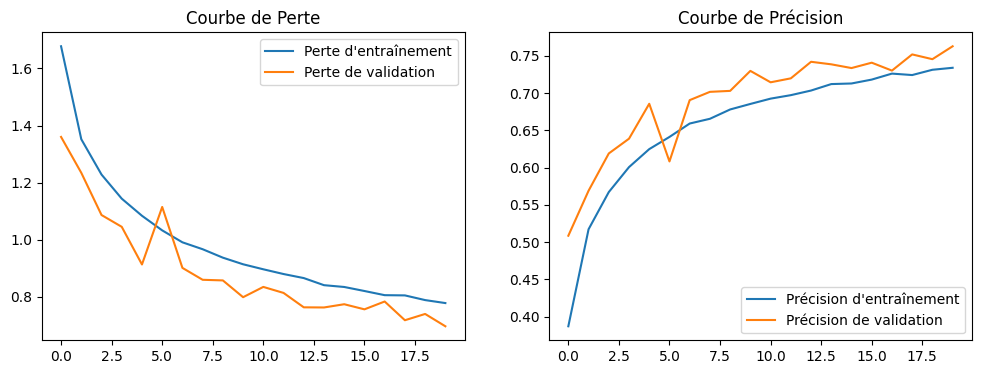

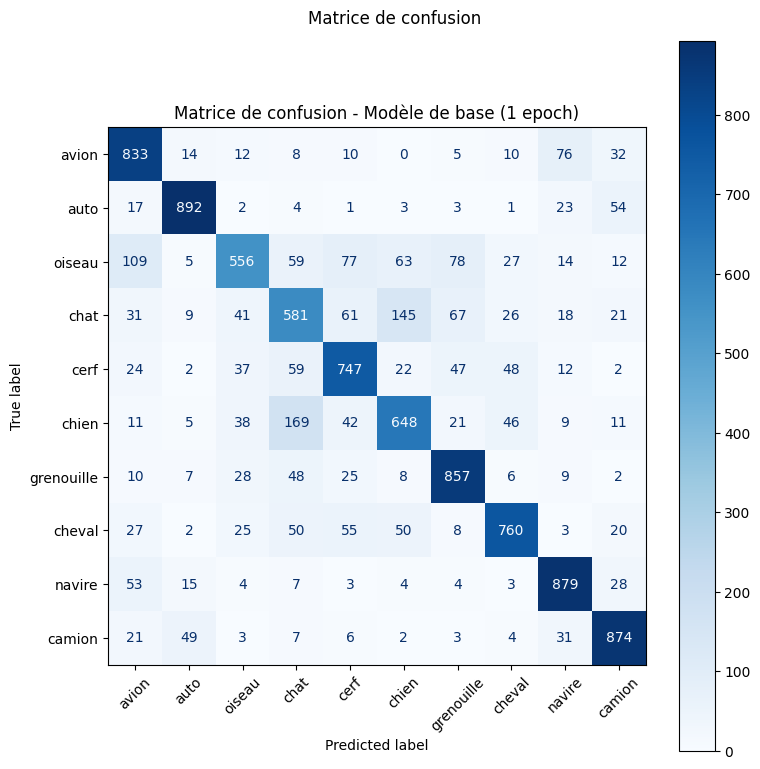

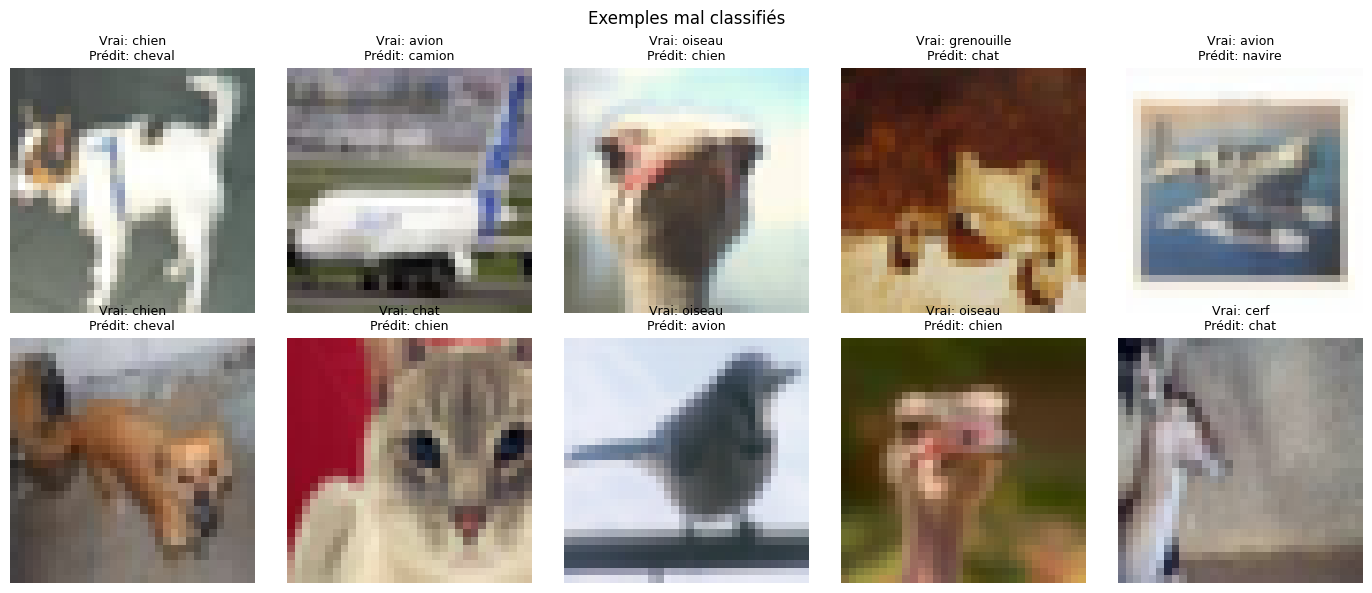

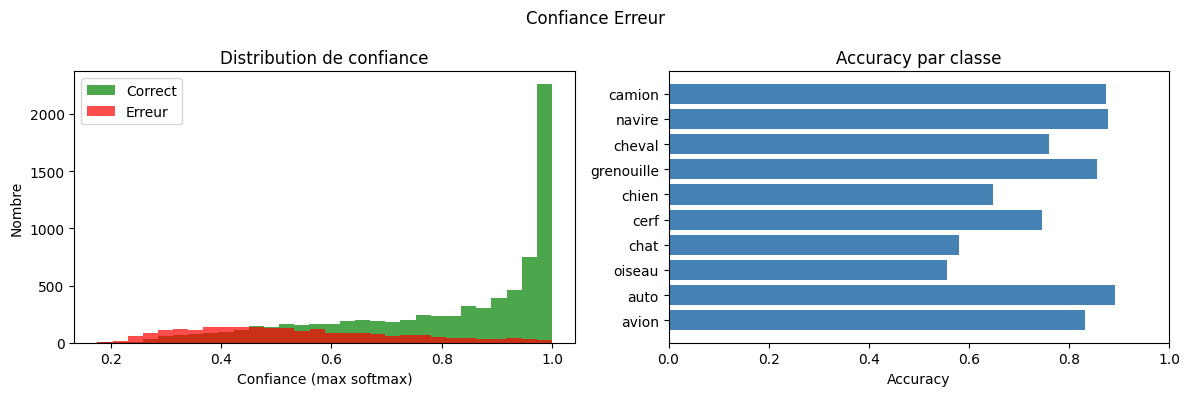

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.1150 - accuracy: 0.6205 - 83ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.6205
64/64 [==============================] - 0s 428us/step


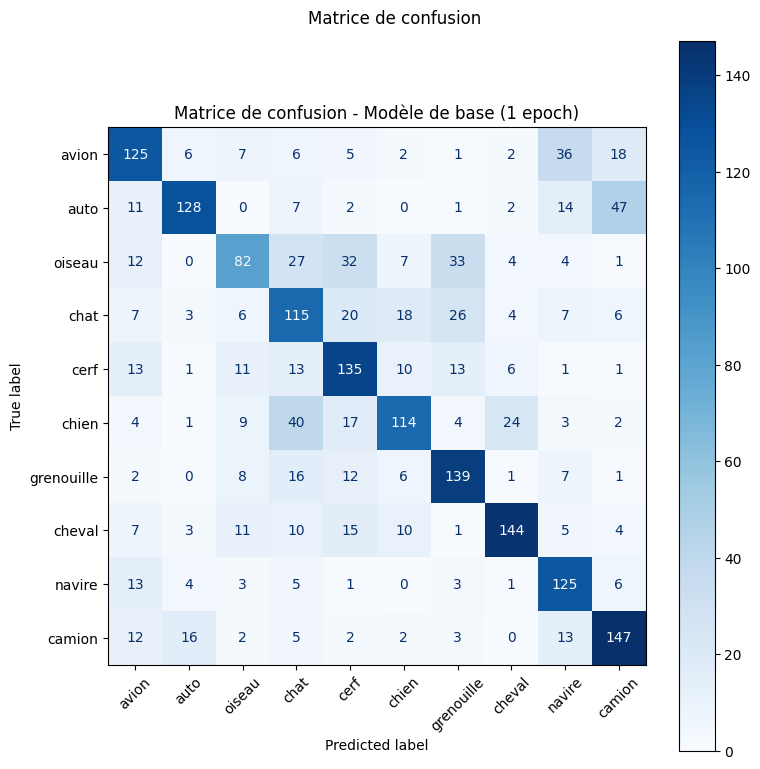

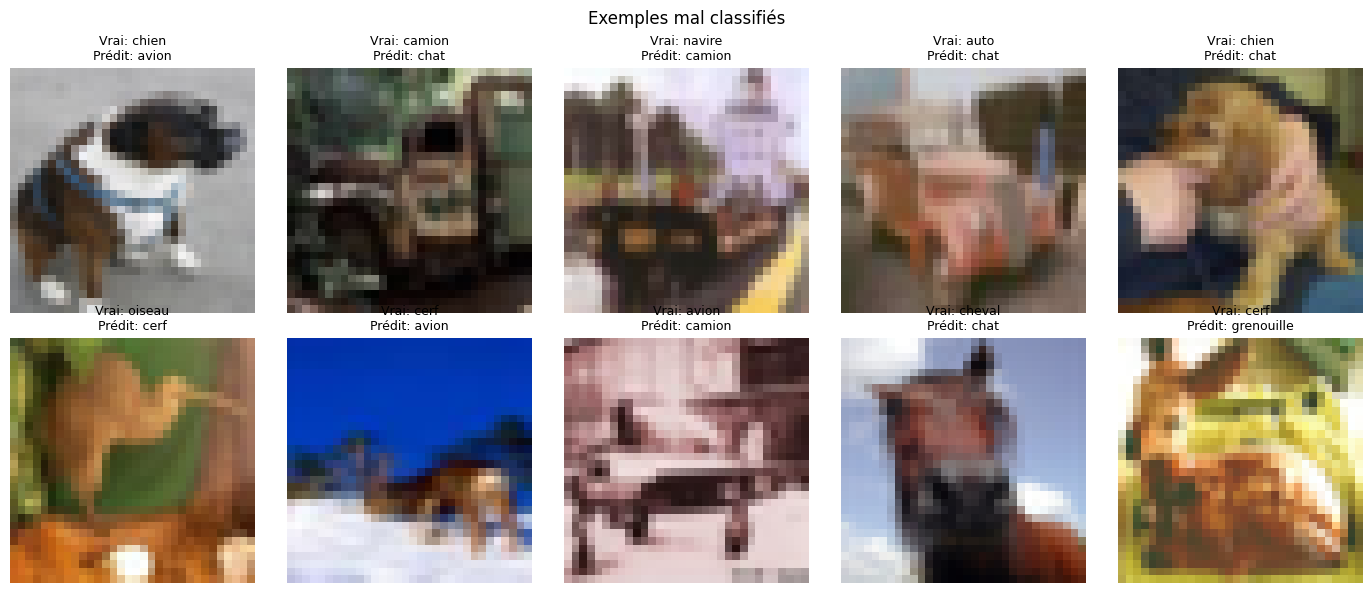

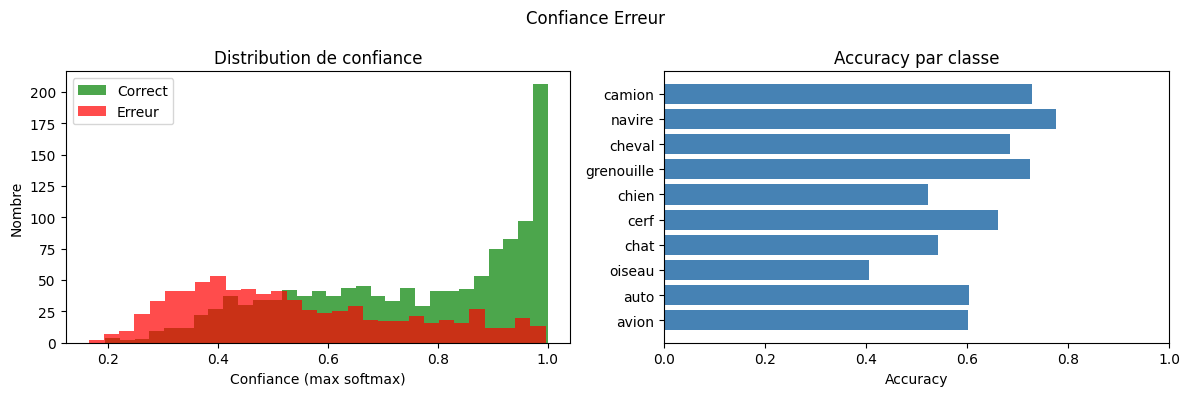

98376

In [4]:
# Définition du modèle CNN
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), #Ajout
    layers.Dropout(0.5), #Ajout
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_03_cnn_dropout_bn",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="Adam",
    augmentation="none",
    regularization="BatchNorm+Dropout+EarlyStopping",
    notes="20 epochs"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


W0000 00:00:1775942513.522161     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.523746     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.523800     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.523839     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.523865     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.523923     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.523973     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.524006     568 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.524039     568 gp

 128/1563 [=>............................] - ETA: 1s - loss: 2.6471 - accuracy: 0.1748

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775942513.774264     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.774310     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942513.774333     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be 

1534/1563 [============================>.] - ETA: 0s - loss: 1.8469 - accuracy: 0.3274

...

1563/1563 [==============================] - 2s 1ms/step - loss: 0.9575 - accuracy: 0.6679 - val_loss: 0.9136 - val_accuracy: 0.6812
Epoch 13/100
   1/1563 [..............................] - ETA: 2s - loss: 0.7699 - accuracy: 0.8125

W0000 00:00:1775942535.711697     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711748     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711775     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711805     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711830     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711860     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711899     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711931     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942535.711962     566 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 0.9472 - accuracy: 0.6735 - val_loss: 0.7930 - val_accuracy: 0.7239
Epoch 14/100
   1/1563 [..............................] - ETA: 2s - loss: 1.1006 - accuracy: 0.5938

W0000 00:00:1775942537.524694     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524746     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524773     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524802     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524828     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524859     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524899     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524932     573 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942537.524964     573 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 0.9301 - accuracy: 0.6801 - val_loss: 0.8171 - val_accuracy: 0.7133
Epoch 15/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9154 - accuracy: 0.6845 - val_loss: 0.7615 - val_accuracy: 0.7320
Epoch 16/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9043 - accuracy: 0.6903 - val_loss: 0.9172 - val_accuracy: 0.6918
Epoch 17/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.8942 - accuracy: 0.6915 - val_loss: 0.7613 - val_accuracy: 0.7320
Epoch 18/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.8801 - accuracy: 0.6975 - val_loss: 0.7664 - val_accuracy: 0.7335
Epoch 19/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.8775 - accuracy: 0.6996 - val_loss: 0.7785 - val_accuracy: 0.7284
Epoch 20/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.8622 - accuracy: 0.7053 - val_loss: 0.7689 - val_accuracy

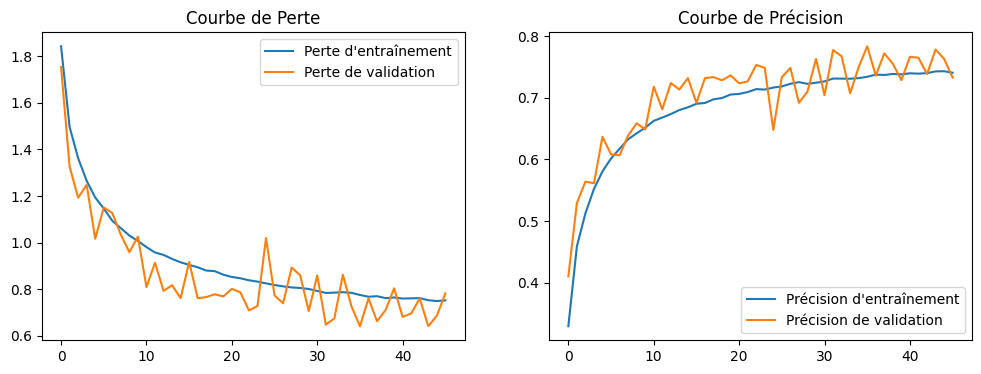

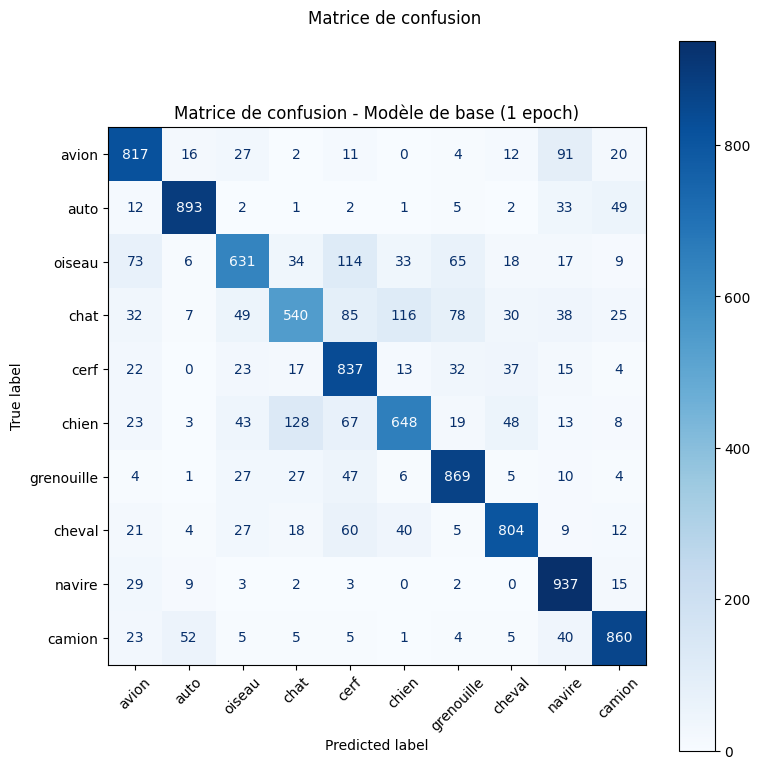

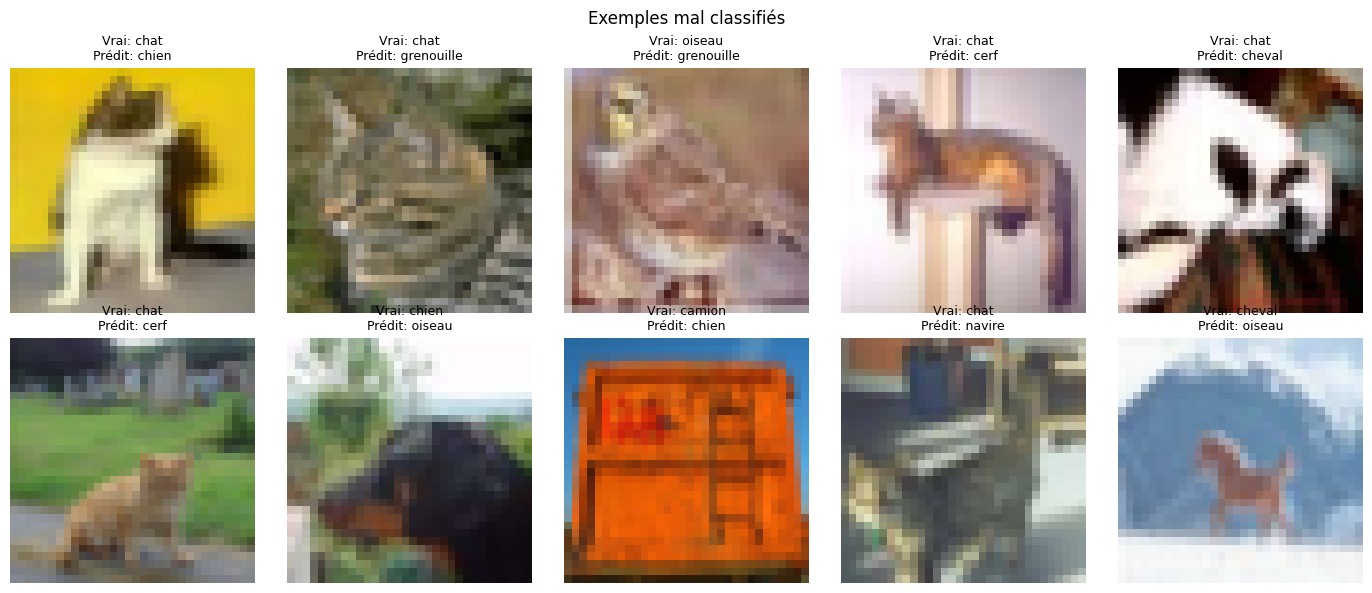

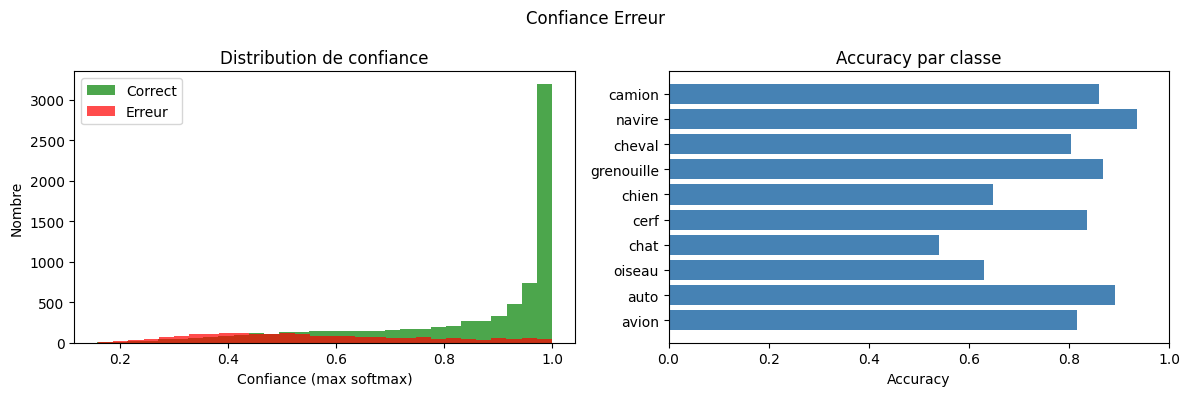

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.0701 - accuracy: 0.6393 - 87ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.6393
64/64 [==============================] - 0s 386us/step


W0000 00:00:1775942599.039116     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039162     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039180     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039197     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039219     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039245     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039265     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039296     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942599.039339     572 gp

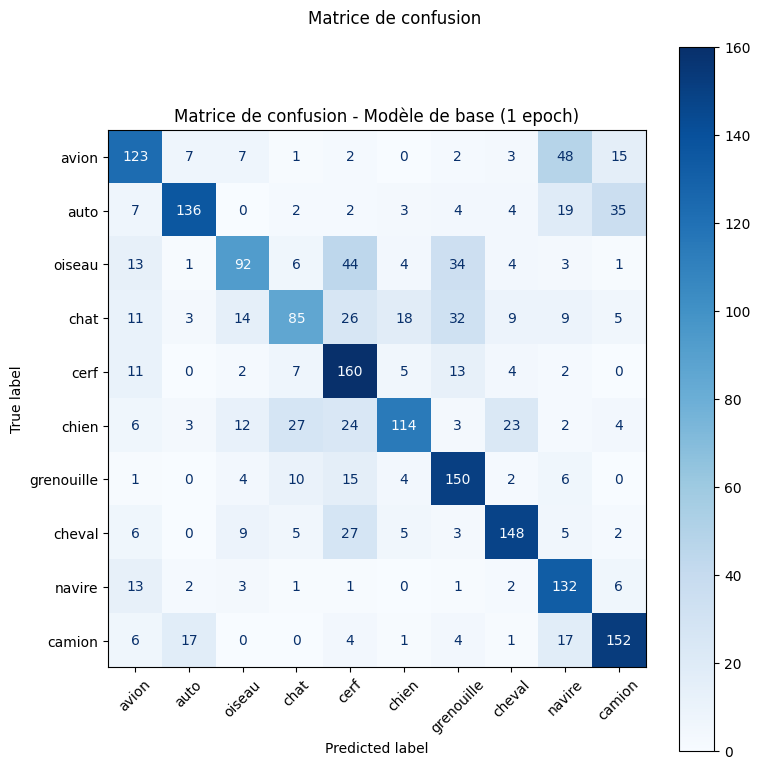

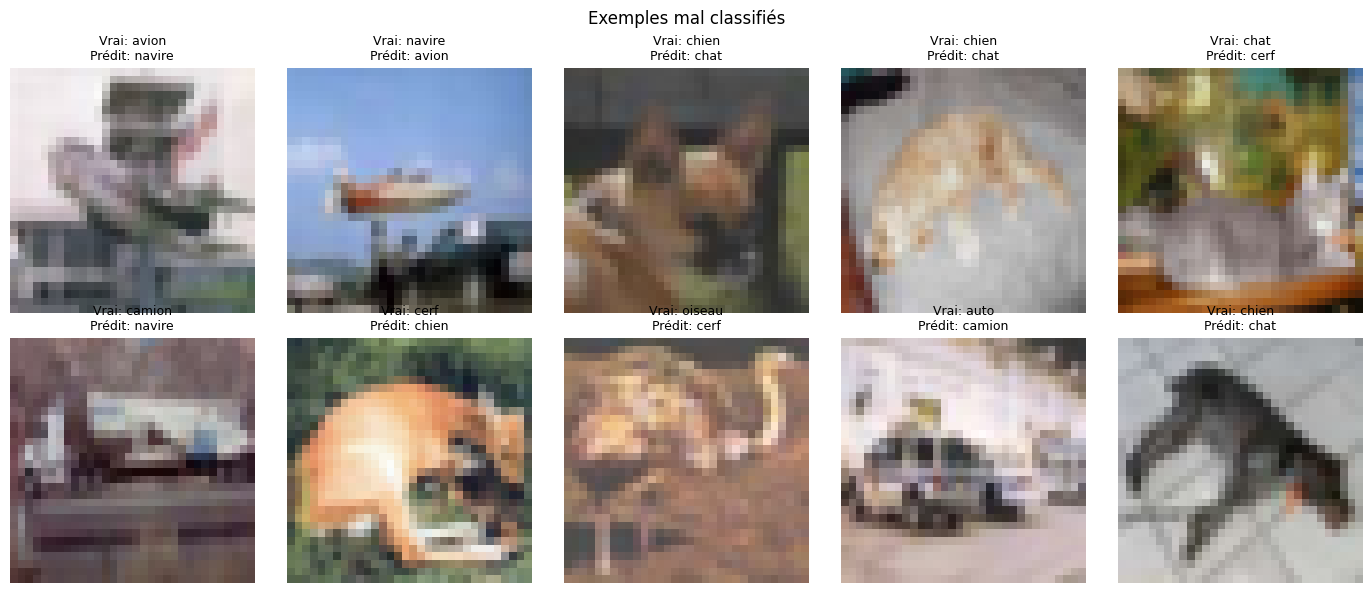

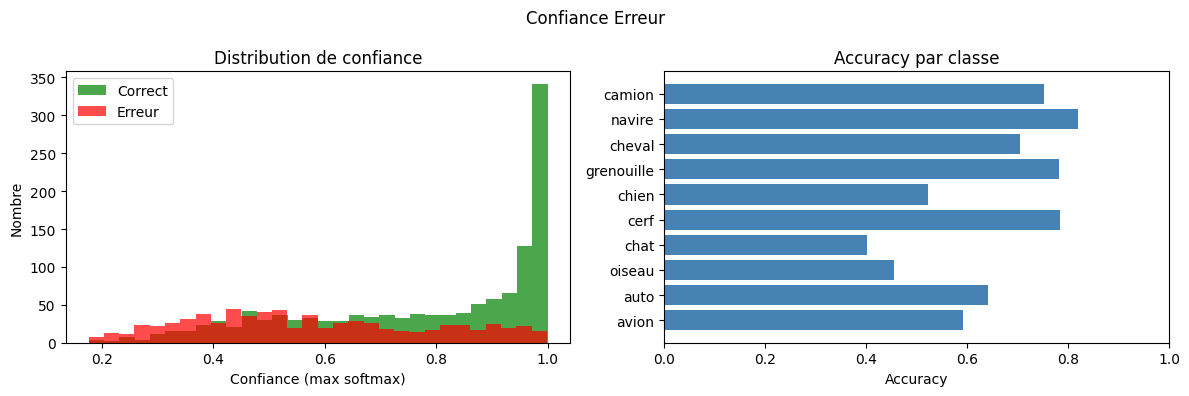

98065

In [5]:
# Définition du modèle CNN avec 
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5)
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_04_cnn_bn_dropout_relu",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="Adam",
    augmentation="none",
    regularization="BatchNorm+Dropout+EarlyStopping",
    notes="ReLU blocks"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 10:14 - loss: 4.8772 - accuracy: 0.1250

W0000 00:00:1775942600.583370     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583435     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583460     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583503     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583526     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583549     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583595     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583631     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942600.583688     570 gp

1562/1563 [============================>.] - ETA: 0s - loss: 2.0519 - accuracy: 0.2517

W0000 00:00:1775942602.405151     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405194     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405212     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405233     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405263     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405287     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405309     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405365     570 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942602.405406     570 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 2.0519 - accuracy: 0.2517 - val_loss: 1.7188 - val_accuracy: 0.3405
Epoch 2/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.6899 - accuracy: 0.3938 - val_loss: 1.4277 - val_accuracy: 0.4917
Epoch 3/100
   1/1563 [..............................] - ETA: 2s - loss: 1.4059 - accuracy: 0.4688

W0000 00:00:1775942604.357707     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.357771     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.357807     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.357865     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.357907     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.357954     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.357984     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.358021     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942604.358097     569 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 1.4161 - accuracy: 0.4940 - val_loss: 1.4957 - val_accuracy: 0.4734
Epoch 4/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.2735 - accuracy: 0.5527 - val_loss: 1.6313 - val_accuracy: 0.4444
Epoch 5/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1831 - accuracy: 0.5862 - val_loss: 1.0491 - val_accuracy: 0.6348
Epoch 6/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1181 - accuracy: 0.6117 - val_loss: 1.0343 - val_accuracy: 0.6314
Epoch 7/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0679 - accuracy: 0.6315 - val_loss: 0.8778 - val_accuracy: 0.6982
Epoch 8/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0275 - accuracy: 0.6444 - val_loss: 0.9276 - val_accuracy: 0.6721
Epoch 9/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9953 - accuracy: 0.6544 - val_loss: 0.9983 - val_accuracy: 0.65

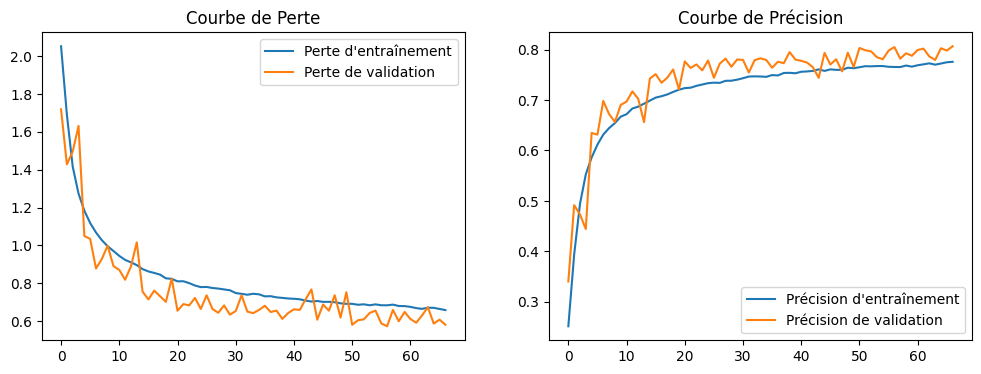

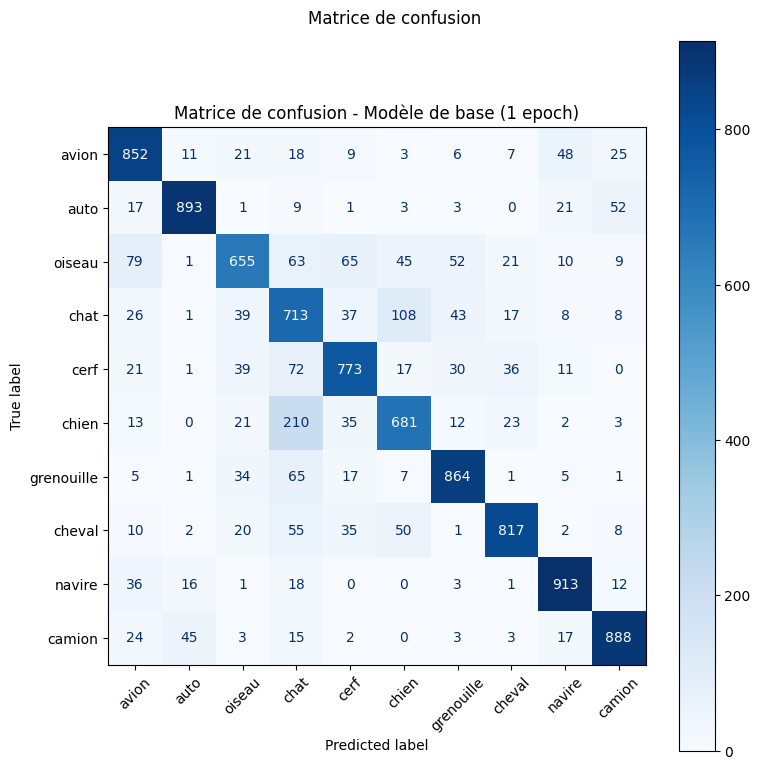

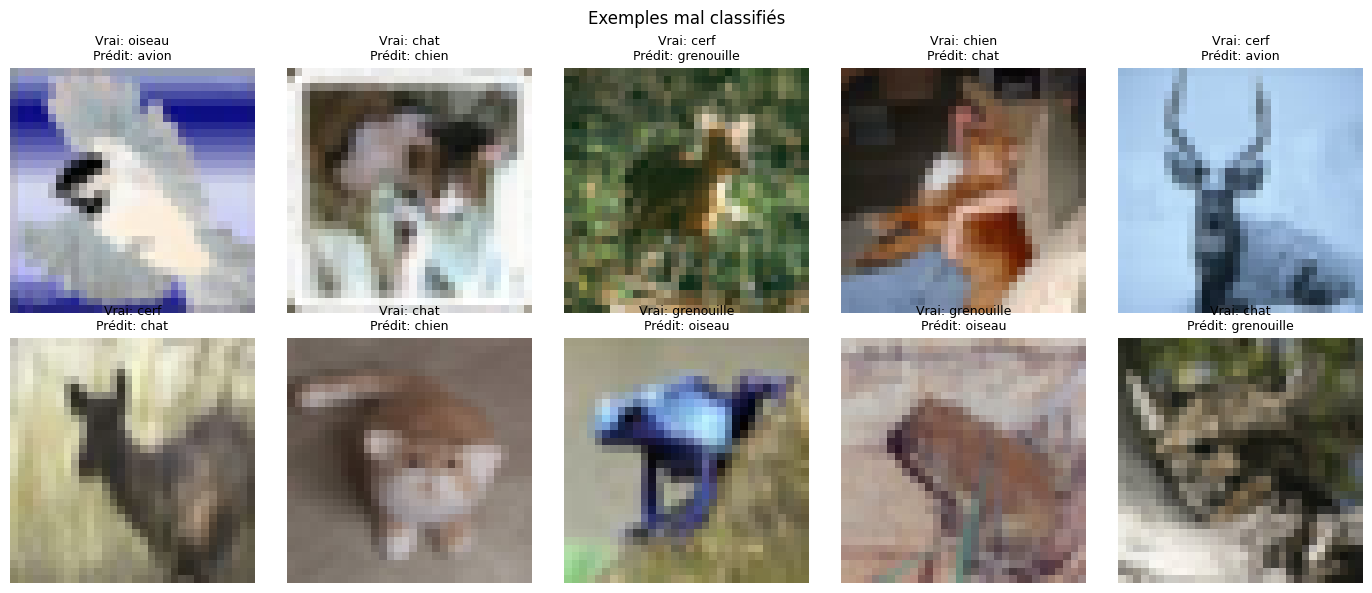

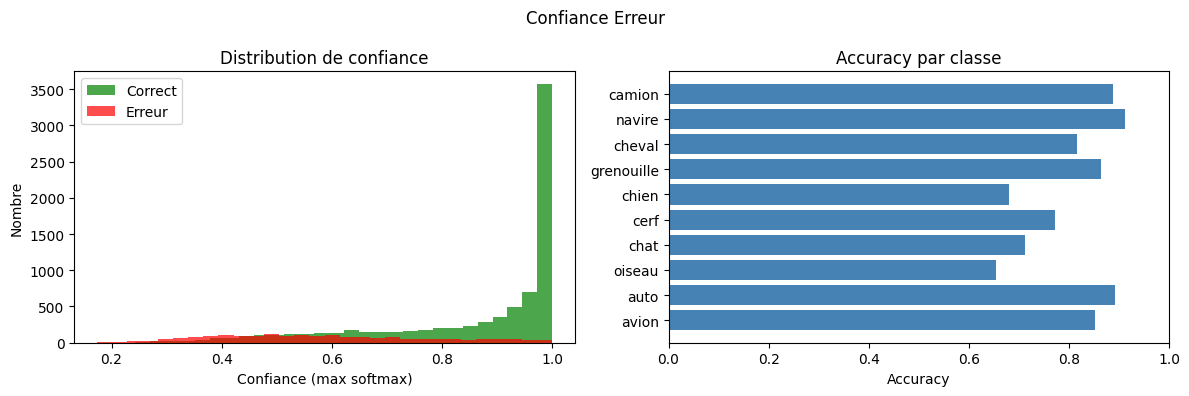

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.9939 - accuracy: 0.6705 - 91ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.6705
64/64 [==============================] - 0s 411us/step


W0000 00:00:1775942723.306722     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306782     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306799     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306818     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306841     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306866     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306886     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306942     567 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942723.306982     567 gp

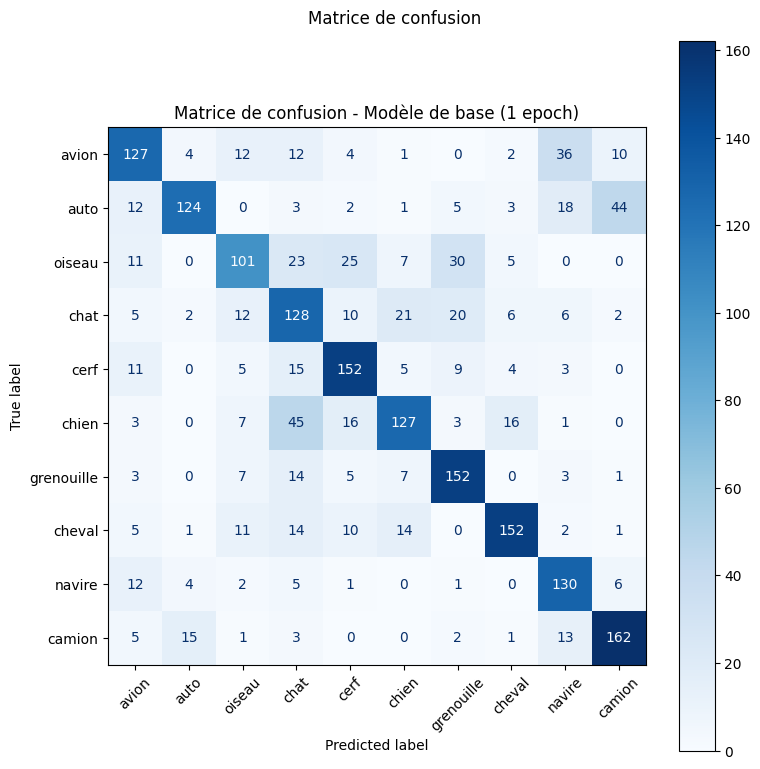

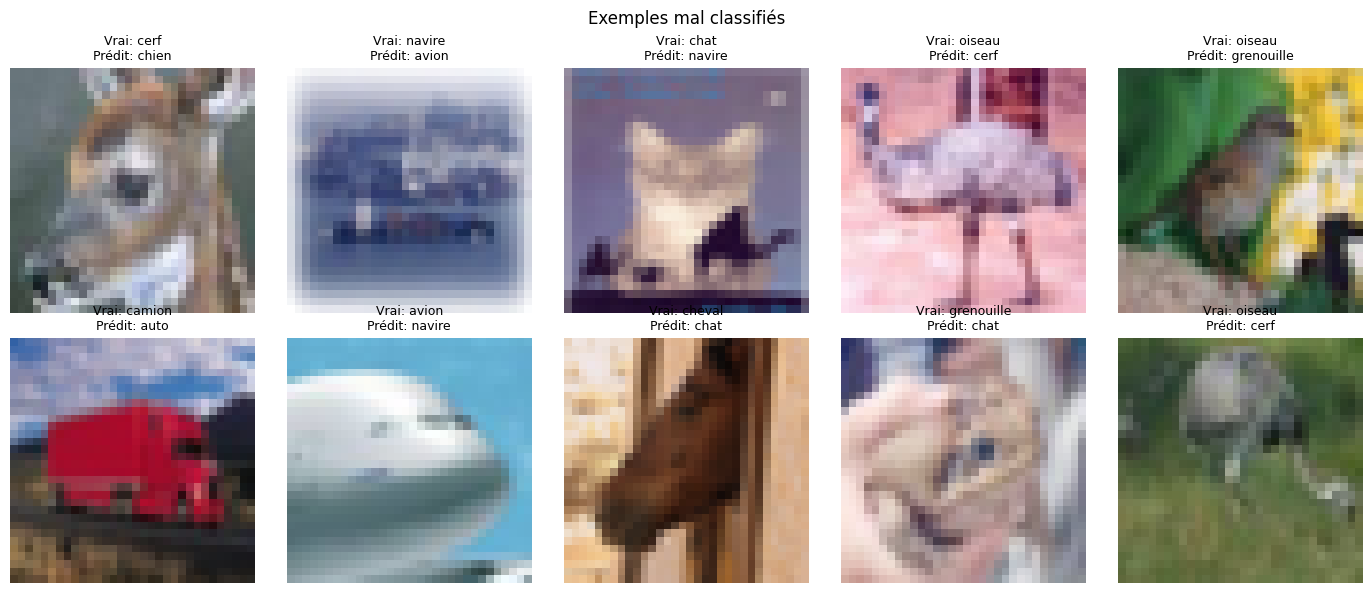

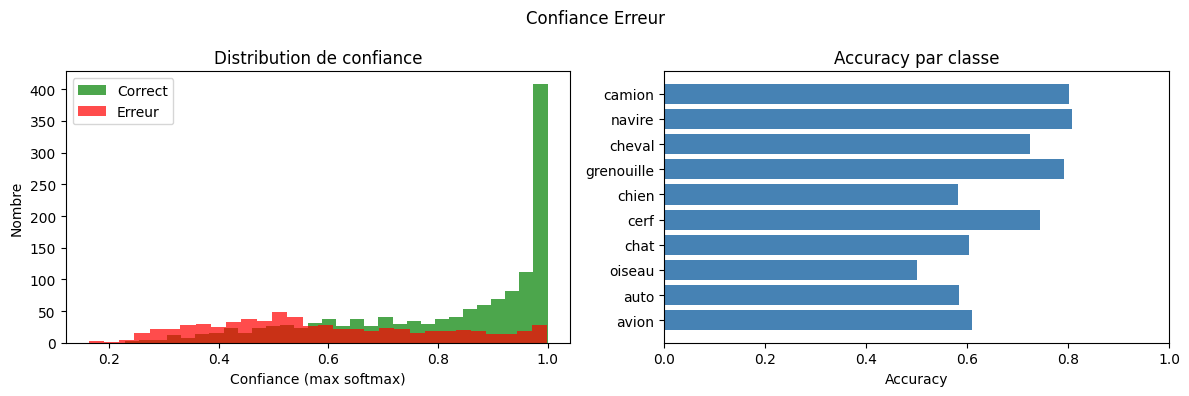

99423

In [6]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_05_cnn_swish_sgd",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.01,m=0.9)",
    augmentation="none",
    regularization="BatchNorm+Dropout+EarlyStopping+ReduceLROnPlateau",
    notes="padding same"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 14:59 - loss: 3.0011 - accuracy: 0.0938

W0000 00:00:1775942724.990080     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990142     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990175     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990213     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990249     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990286     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990328     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990371     572 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942724.990446     572 gp

1563/1563 [==============================] - ETA: 0s - loss: 1.5520 - accuracy: 0.4583

W0000 00:00:1775942727.734147     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734202     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734232     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734263     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734296     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734330     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734365     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734402     566 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942727.734436     566 gp

1563/1563 [==============================] - 4s 2ms/step - loss: 1.5520 - accuracy: 0.4583 - val_loss: 1.1388 - val_accuracy: 0.6036 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 3s 2ms/step - loss: 1.0780 - accuracy: 0.6370 - val_loss: 0.9253 - val_accuracy: 0.6922 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9255 - accuracy: 0.6926 - val_loss: 0.8367 - val_accuracy: 0.7233 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8333 - accuracy: 0.7274 - val_loss: 0.7593 - val_accuracy: 0.7538 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.7677 - accuracy: 0.7507 - val_loss: 0.7053 - val_accuracy: 0.7724 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.7210 - accuracy: 0.7681 - val_loss: 0.6776 - val_accuracy: 0.7829 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 3s 2ms/

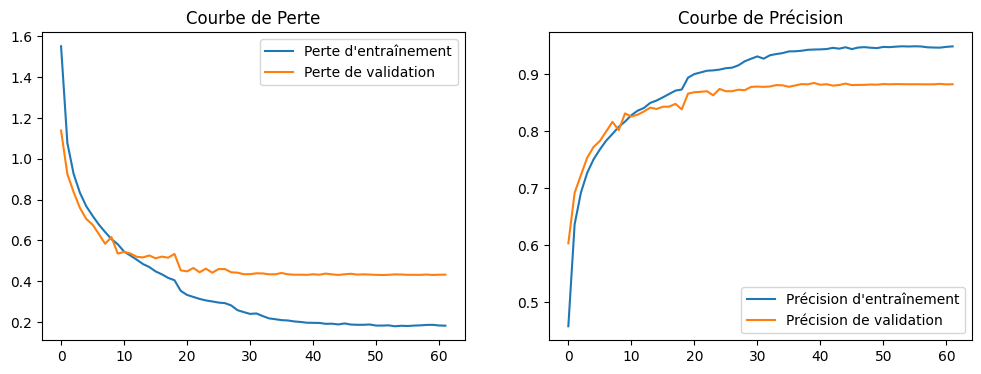

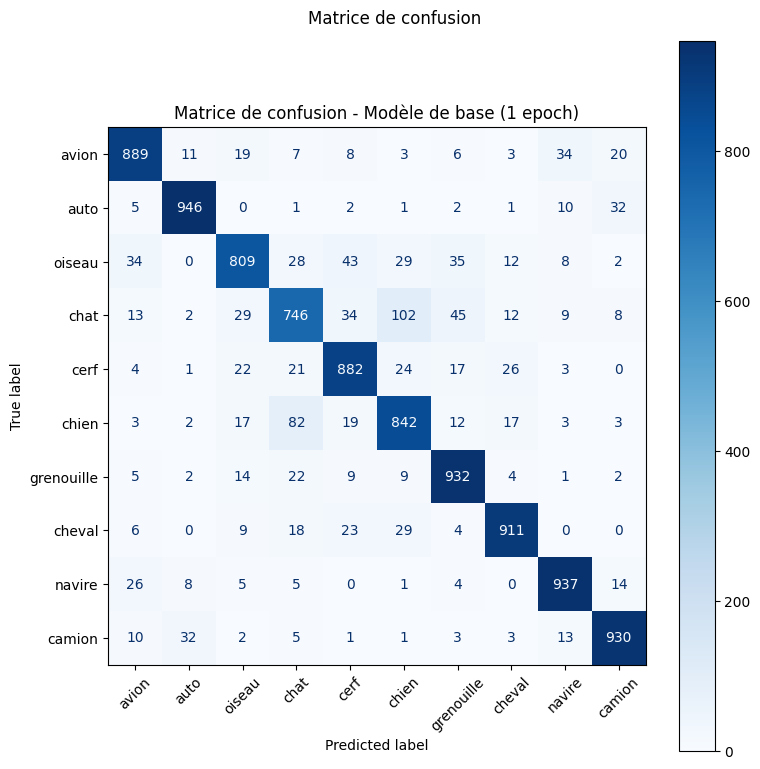

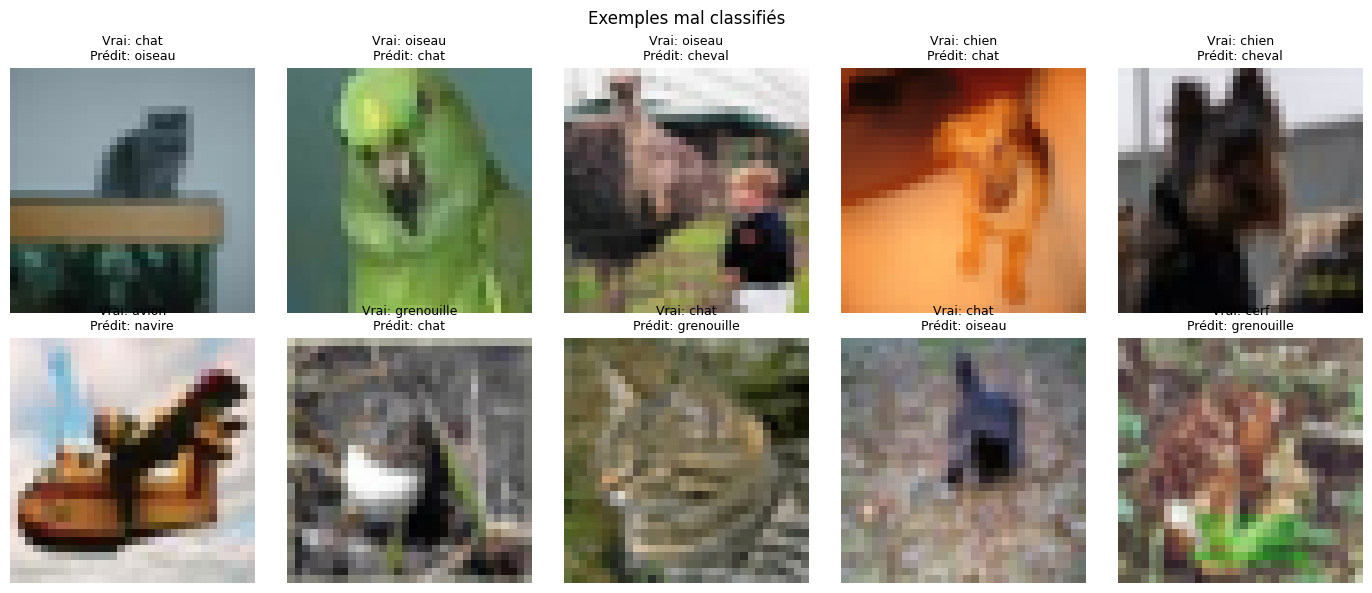

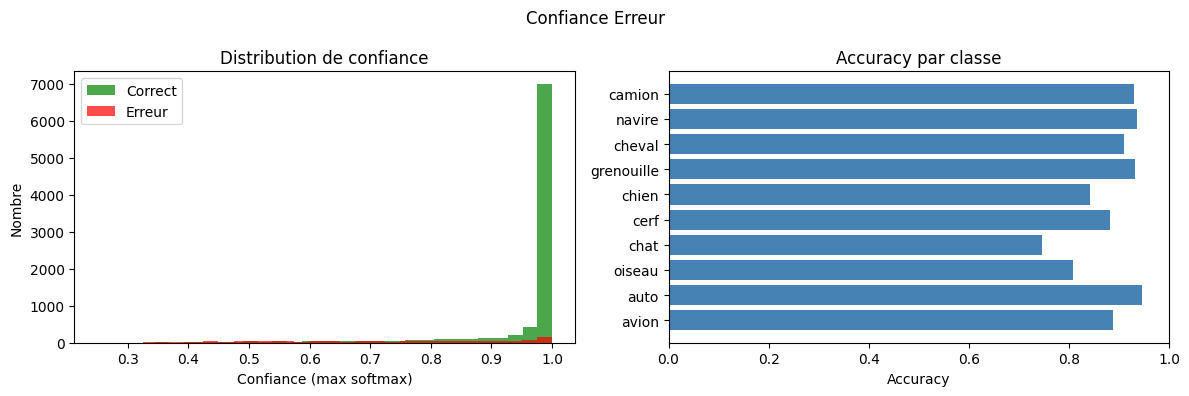

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.8752 - accuracy: 0.7793 - 121ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7793
64/64 [==============================] - 0s 526us/step


W0000 00:00:1775942898.344133     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344184     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344212     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344241     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344262     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344292     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344320     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344353     569 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775942898.344513     569 gp

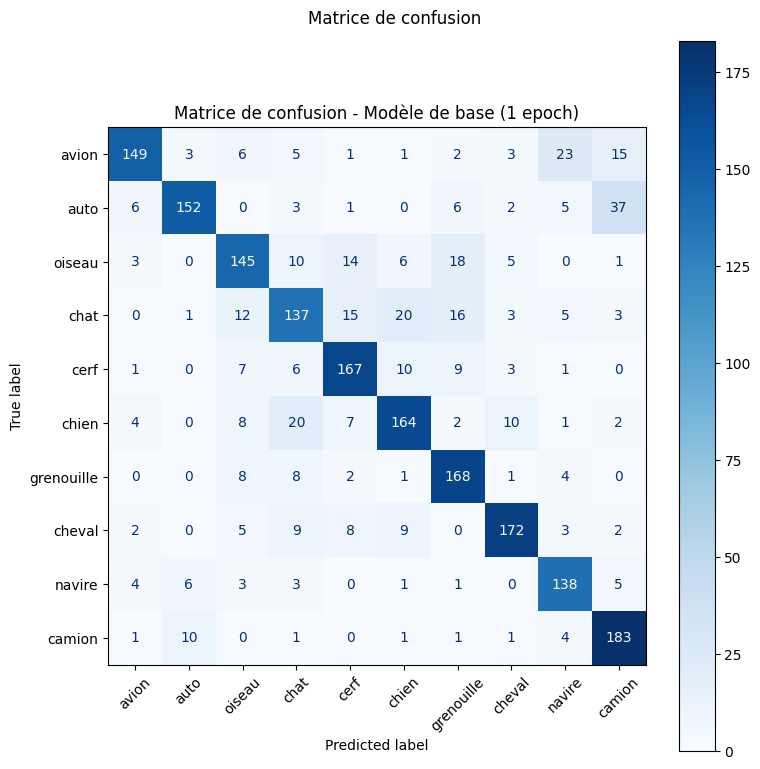

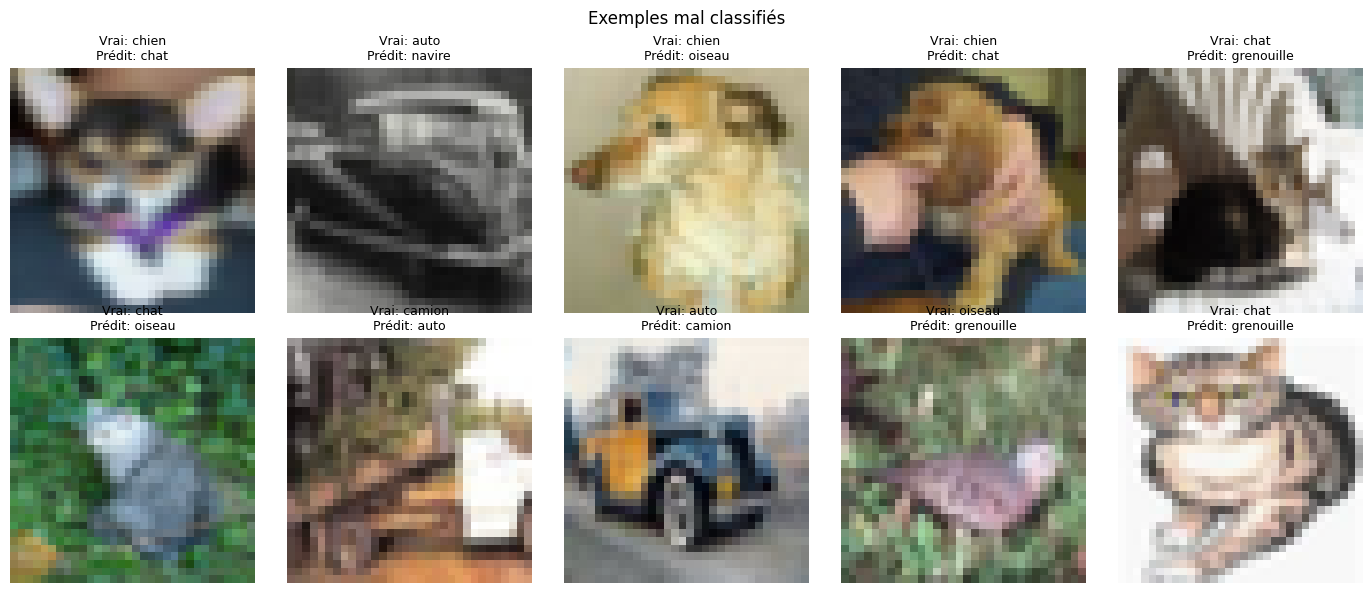

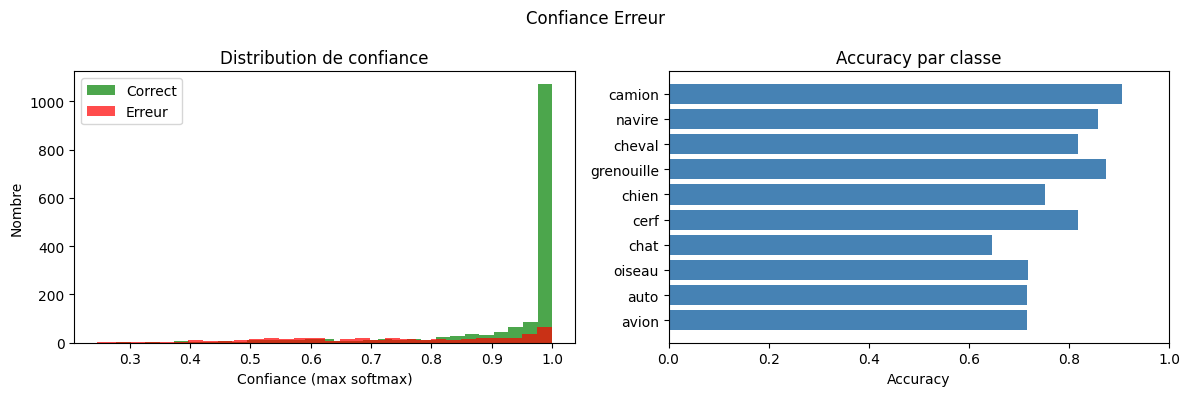

97279

In [7]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_06_cnn_deeper_l2",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.01,m=0.9)",
    augmentation="none",
    regularization="BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnPlateau",
    notes="double conv blocks"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
  30/1563 [..............................] - ETA: 2s - loss: 2.6492 - accuracy: 0.1427   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.4985 - accuracy: 0.4772 - val_loss: 1.1184 - val_accuracy: 0.6097 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 3s 2ms/step - loss: 1.0696 - accuracy: 0.6393 - val_loss: 0.9563 - val_accuracy: 0.6836 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9200 - accuracy: 0.6949 - val_loss: 0.7904 - val_accuracy: 0.7422 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8388 - accuracy: 0.7223 - val_loss: 0.7543 - val_accuracy: 0.7526 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.7743 - accuracy: 0.7467 - val_loss: 0.6644 - val_accuracy: 0.7886 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.7199 - accuracy: 0.7658 - val_loss: 0.6971 - val_accuracy: 0.7784 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 3s 2ms/

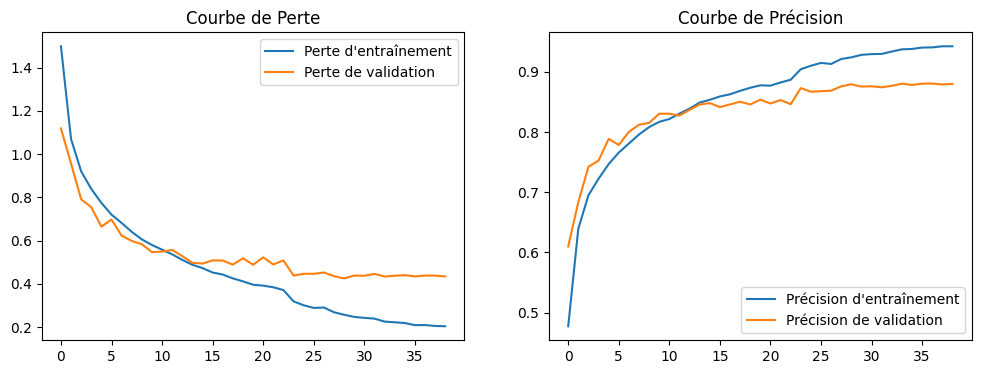

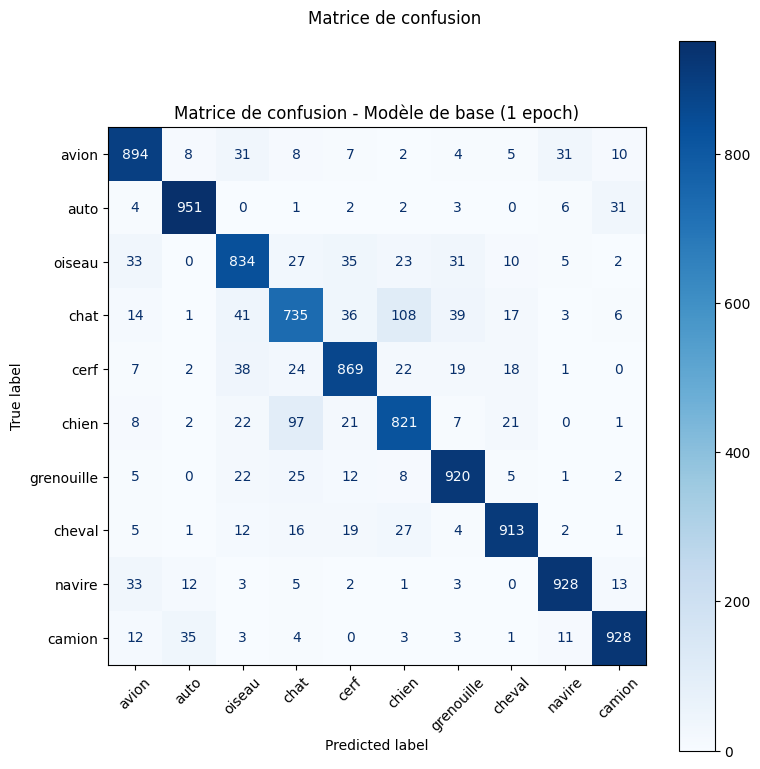

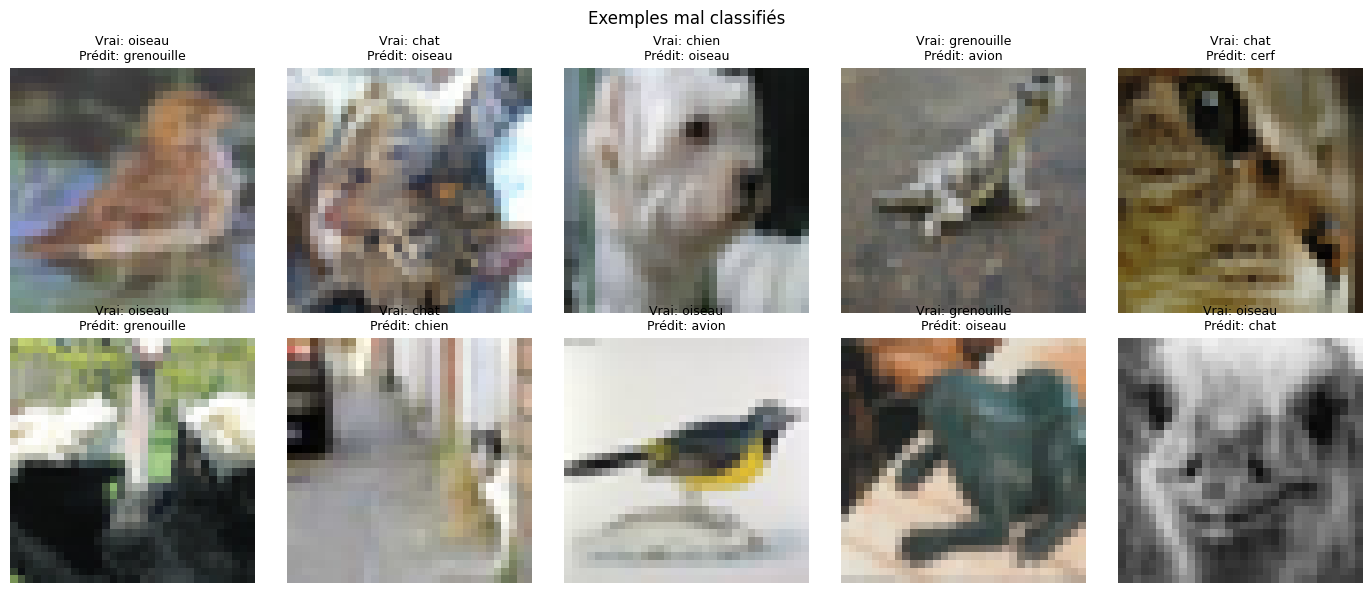

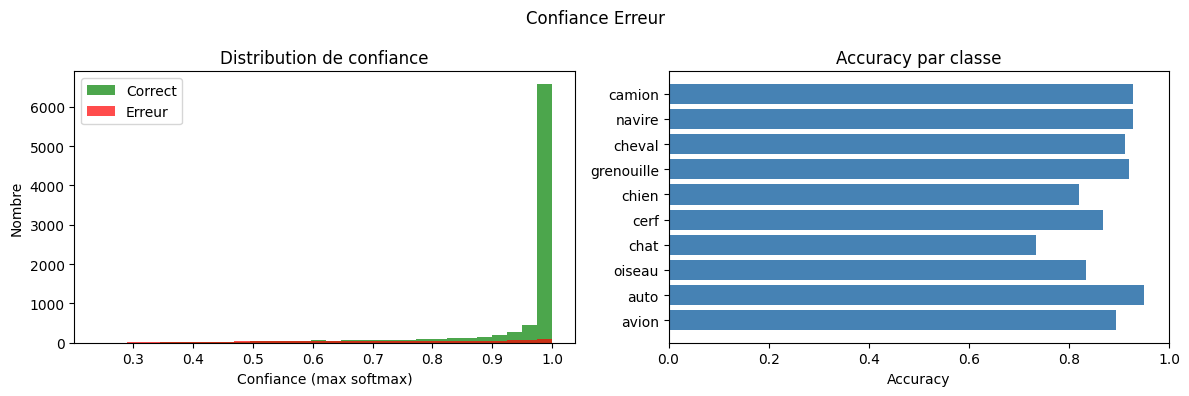

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.8362 - accuracy: 0.7704 - 117ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7704
64/64 [==============================] - 0s 505us/step


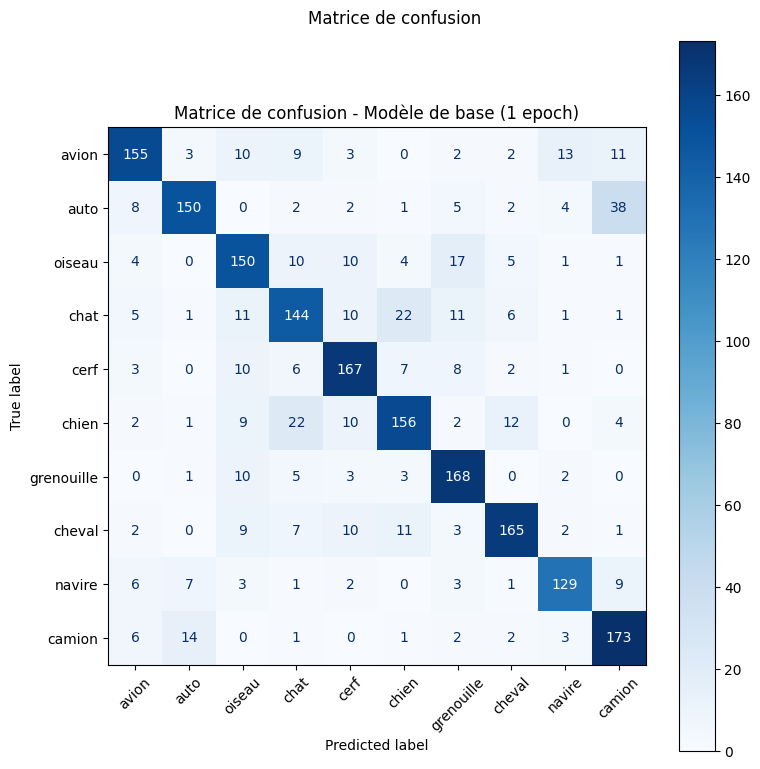

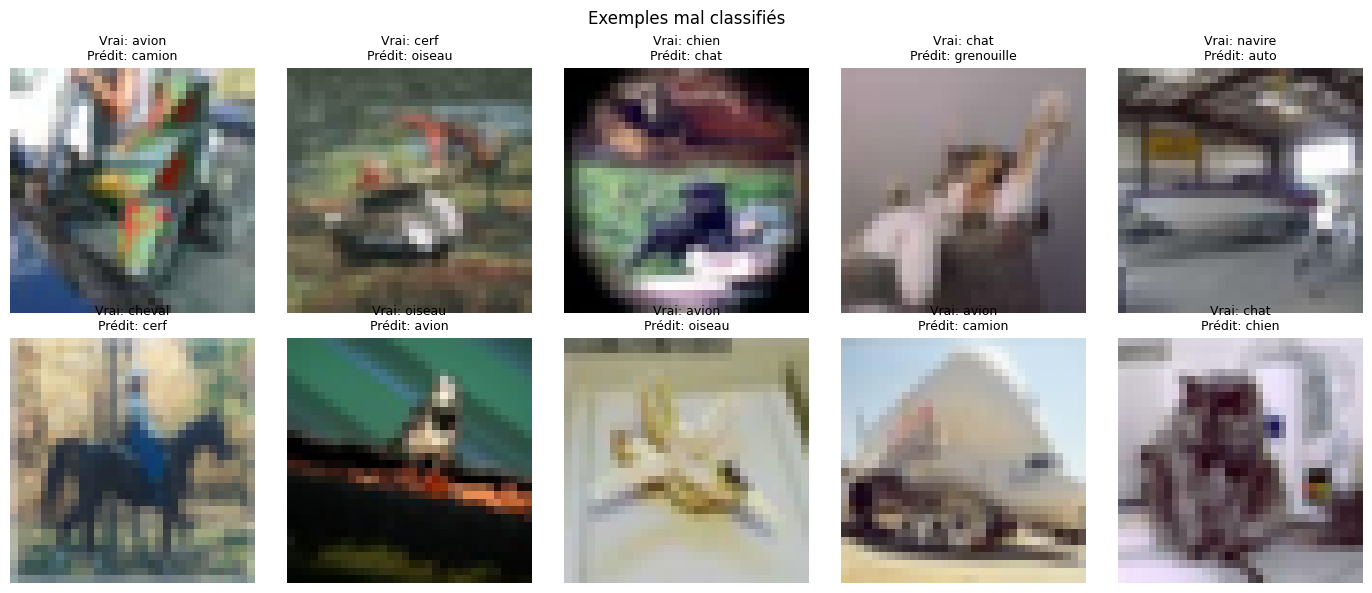

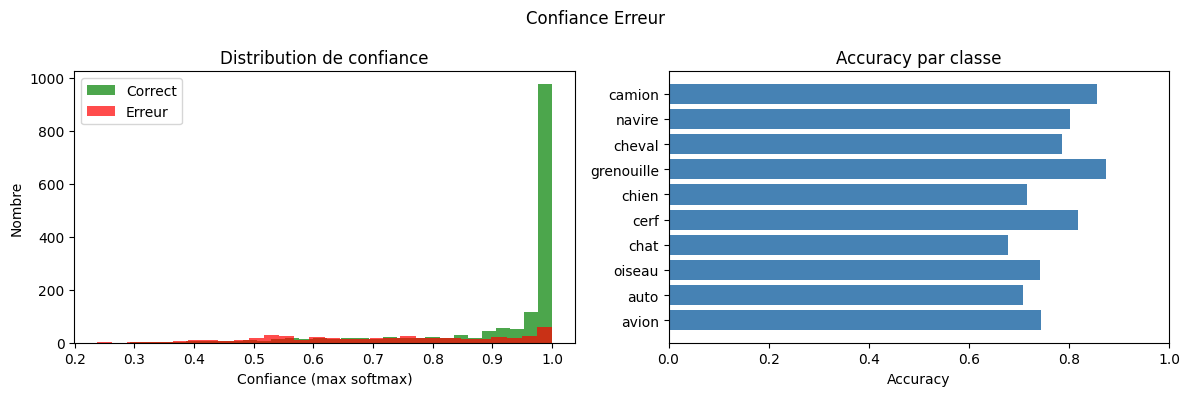

98552

In [8]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_07_cnn_deeper_l2_bn_act",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.01,m=0.9)",
    augmentation="none",
    regularization="BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnPlateau",
    notes="Conv-BN-Activation ordering"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 20:39 - loss: 2.8281 - accuracy: 0.0312

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 5s 3ms/step - loss: 1.7181 - accuracy: 0.3925 - val_loss: 1.5389 - val_accuracy: 0.4877 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.3727 - accuracy: 0.5272 - val_loss: 1.3820 - val_accuracy: 0.5561 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1949 - accuracy: 0.5938 - val_loss: 1.0962 - val_accuracy: 0.6228 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0922 - accuracy: 0.6335 - val_loss: 0.9906 - val_accuracy: 0.6727 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0237 - accuracy: 0.6588 - val_loss: 0.8482 - val_accuracy: 0.7234 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.9753 - accuracy: 0.6780 - val_loss: 0.8864 - val_accuracy: 0.7096 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 4s 2ms/

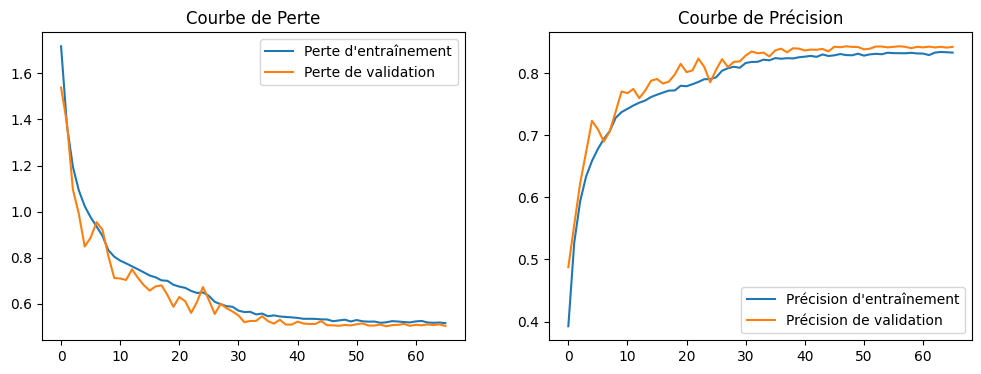

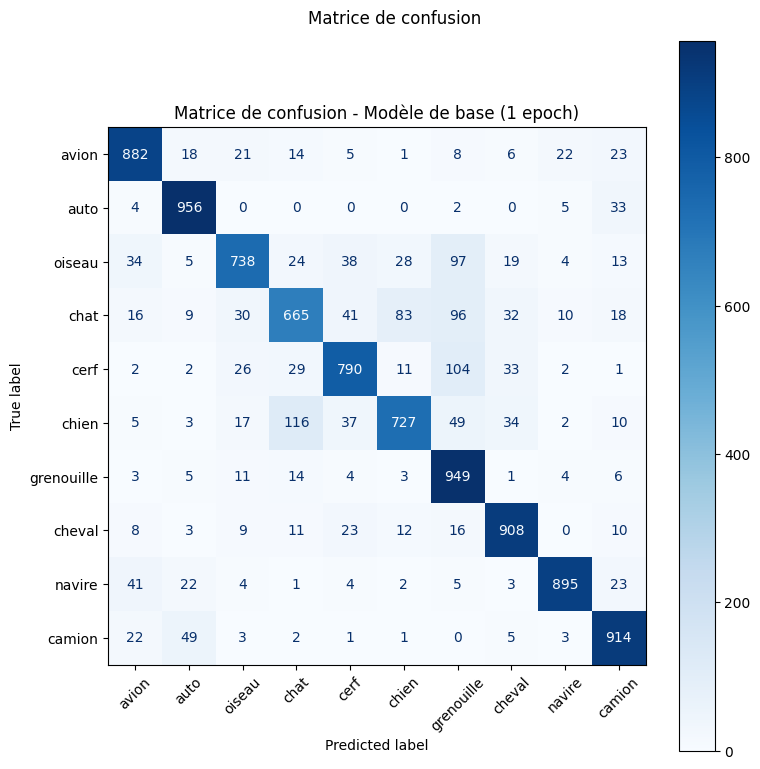

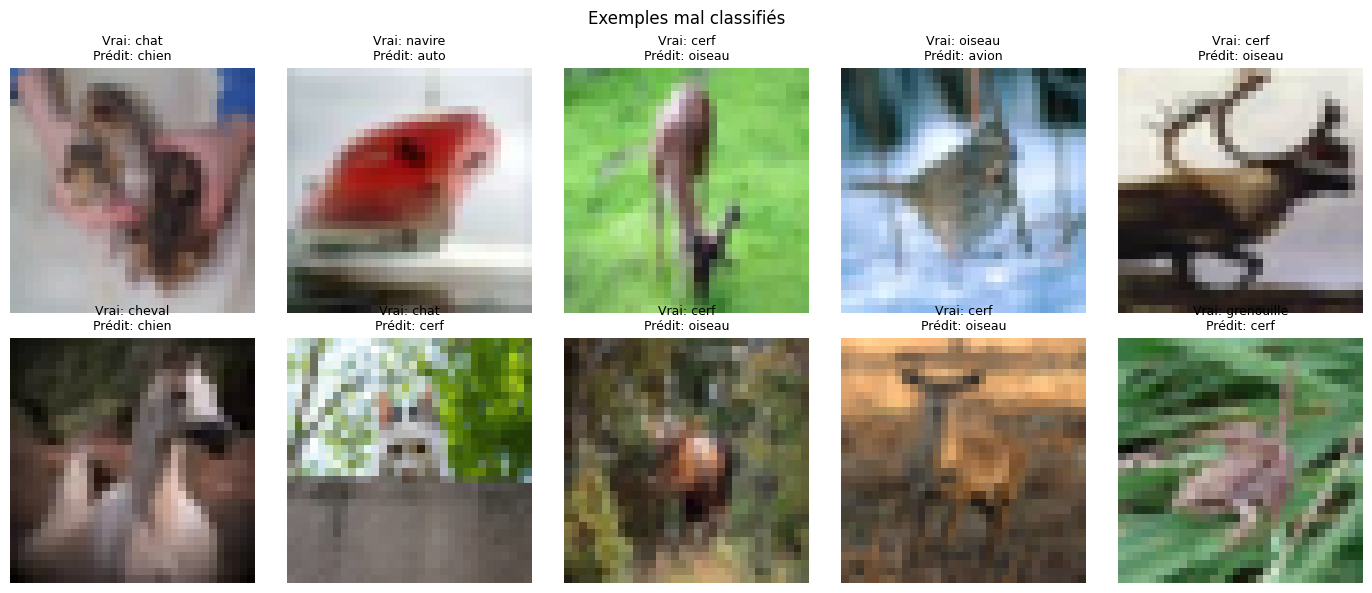

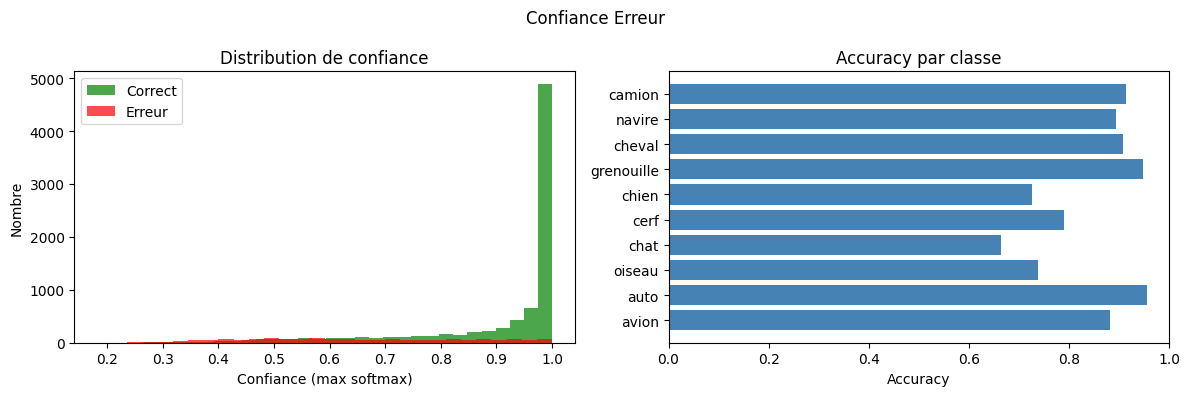

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.8224 - accuracy: 0.7313 - 119ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7313
64/64 [==============================] - 0s 505us/step


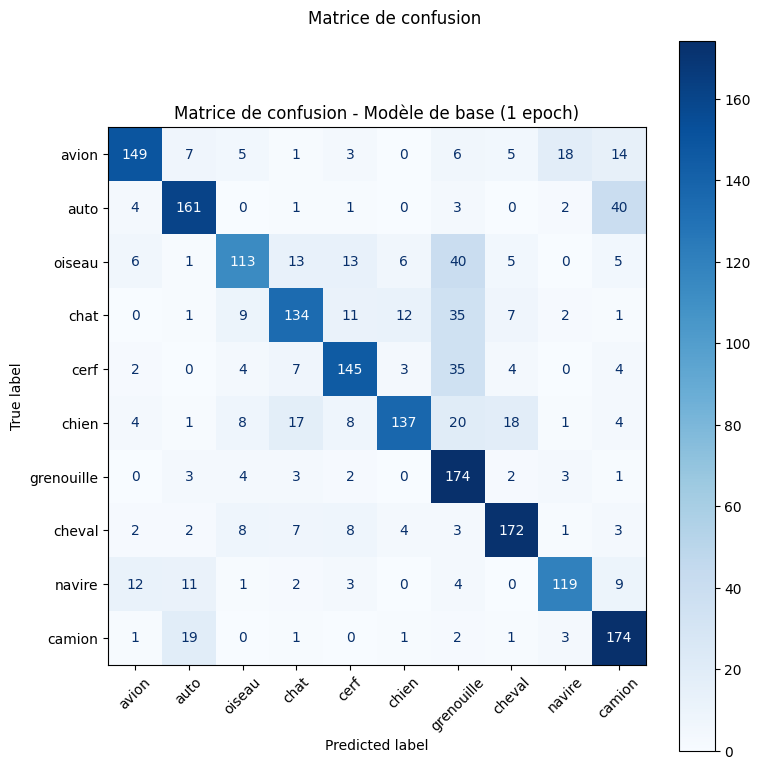

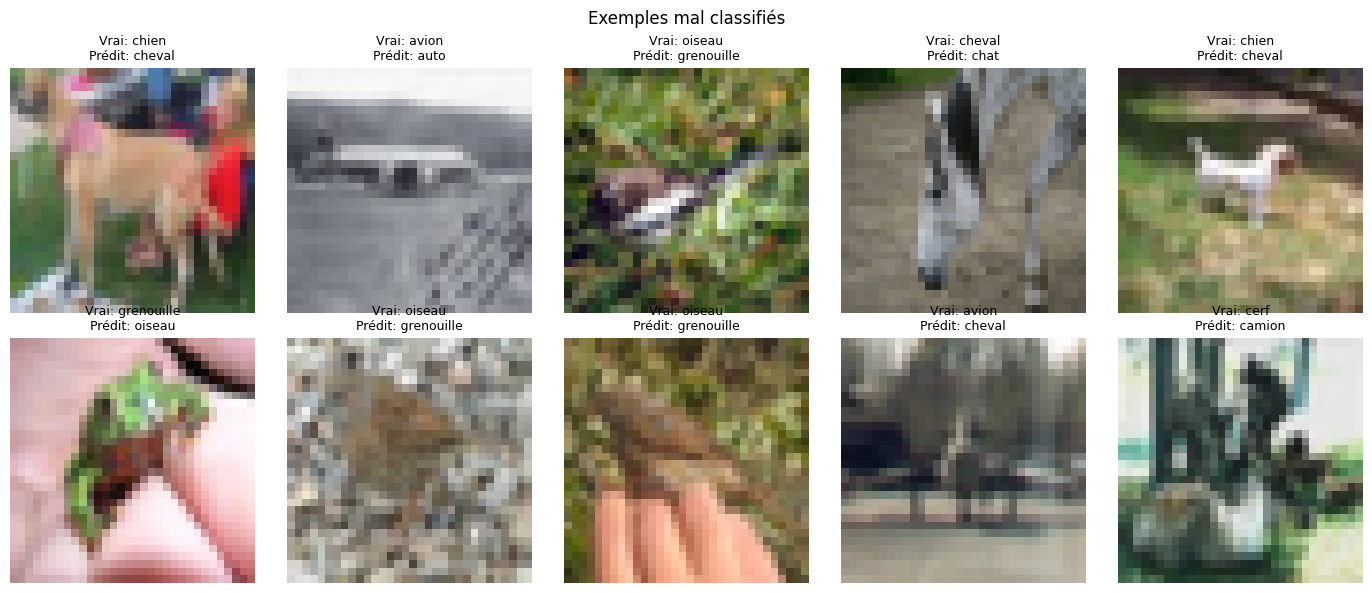

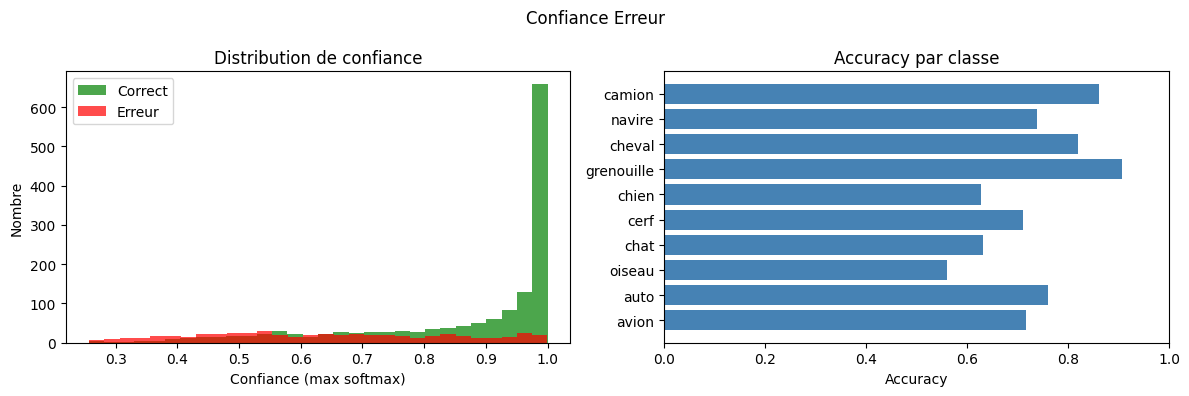

98302

In [9]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - augmentation de données


model = keras.Sequential([
    # Augmentation de données
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),


    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_08_cnn_aug_full",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.01,m=0.9)",
    augmentation="flip+rotation+zoom+translation",
    regularization="BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnPlateau",
    notes="full geometric augmentation"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/200
  25/1563 [..............................] - ETA: 3s - loss: 2.6077 - accuracy: 0.1650   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.6191 - accuracy: 0.4302 - val_loss: 1.2676 - val_accuracy: 0.5707 - lr: 0.0100
Epoch 2/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.1990 - accuracy: 0.5927 - val_loss: 0.9328 - val_accuracy: 0.6923 - lr: 0.0100
Epoch 3/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.0355 - accuracy: 0.6526 - val_loss: 0.9310 - val_accuracy: 0.6877 - lr: 0.0100
Epoch 4/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9435 - accuracy: 0.6892 - val_loss: 0.7975 - val_accuracy: 0.7398 - lr: 0.0100
Epoch 5/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8805 - accuracy: 0.7119 - val_loss: 0.7268 - val_accuracy: 0.7660 - lr: 0.0100
Epoch 6/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8308 - accuracy: 0.7293 - val_loss: 0.6601 - val_accuracy: 0.7929 - lr: 0.0100
Epoch 7/200
1563/1563 [==============================] - 3s 2ms/

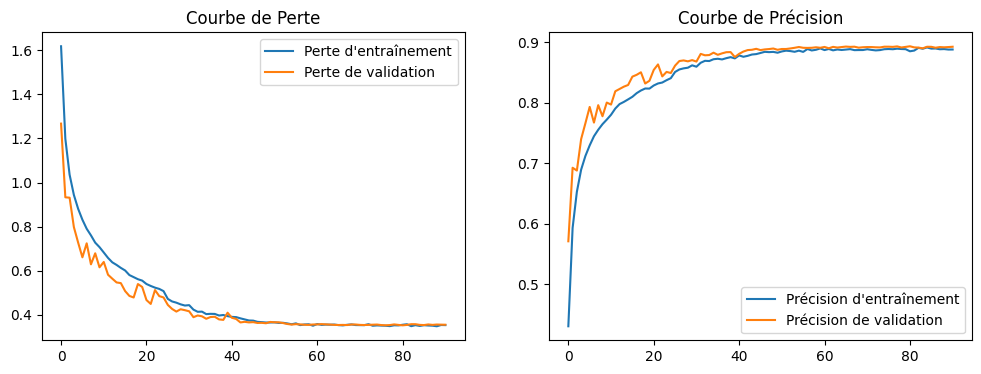

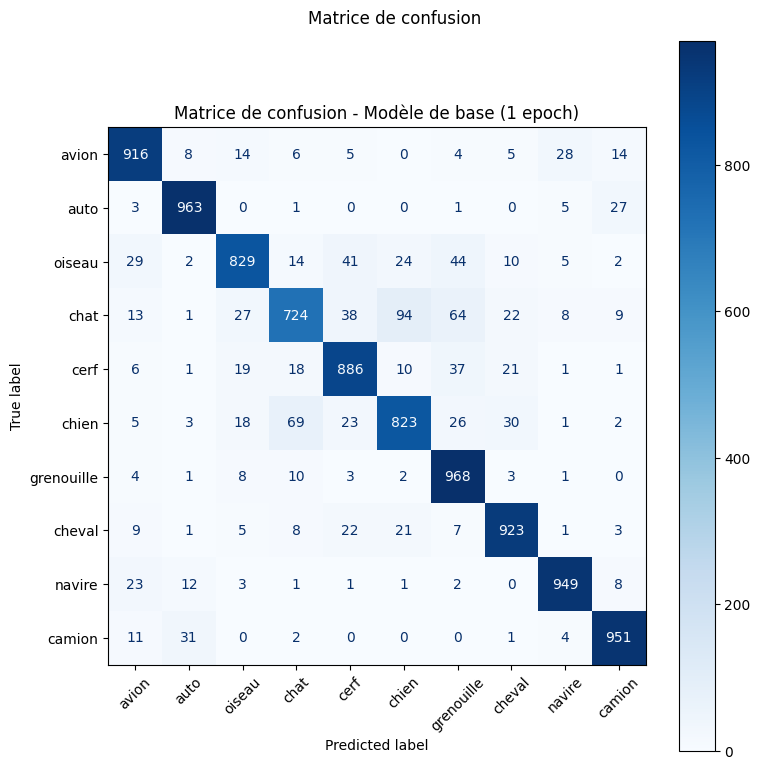

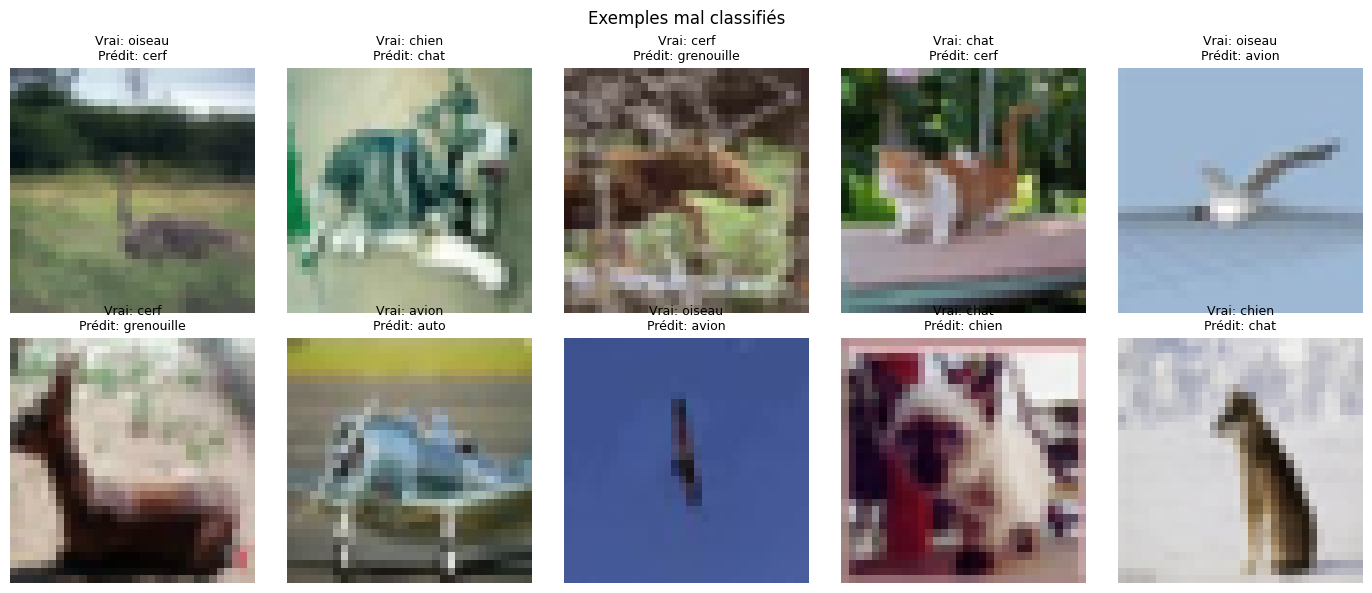

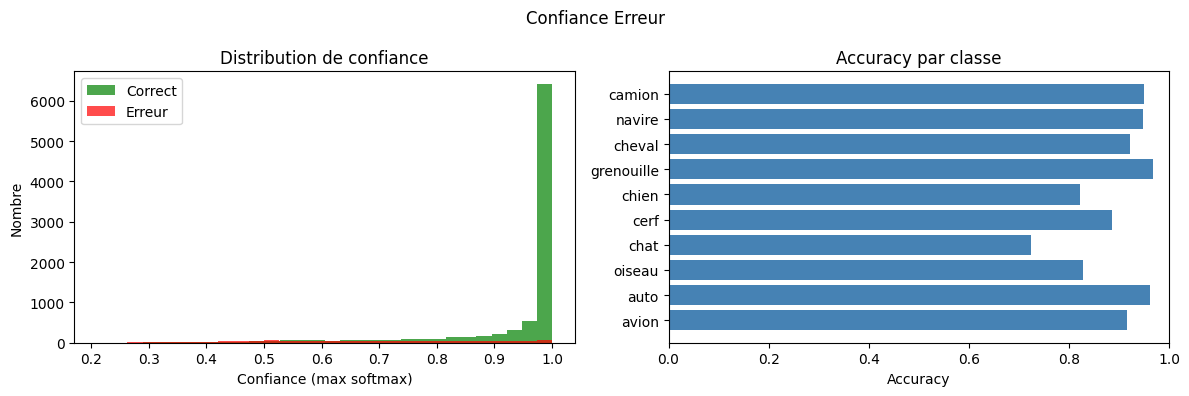

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.6312 - accuracy: 0.8016 - 117ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.8016
64/64 [==============================] - 0s 521us/step


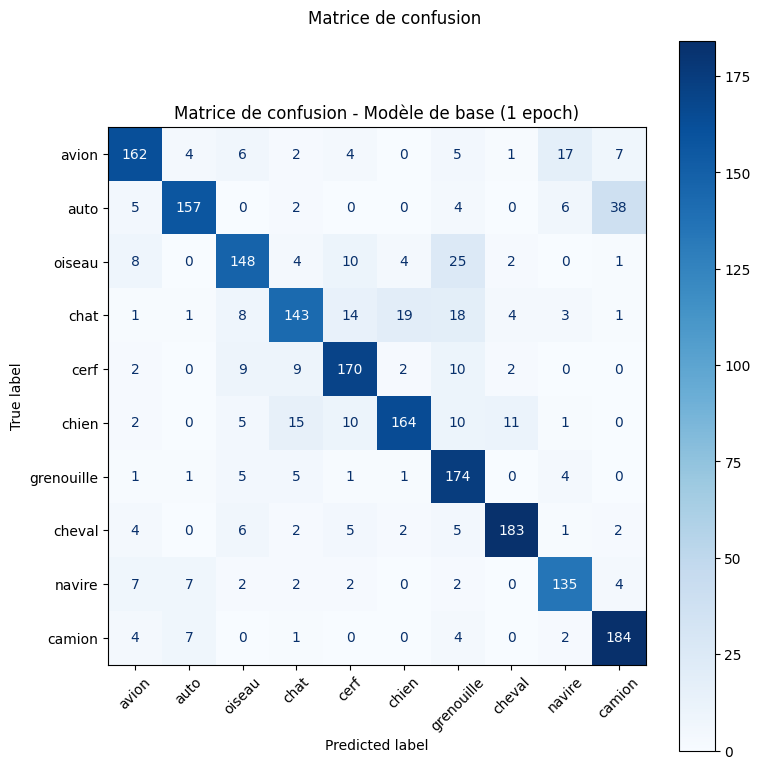

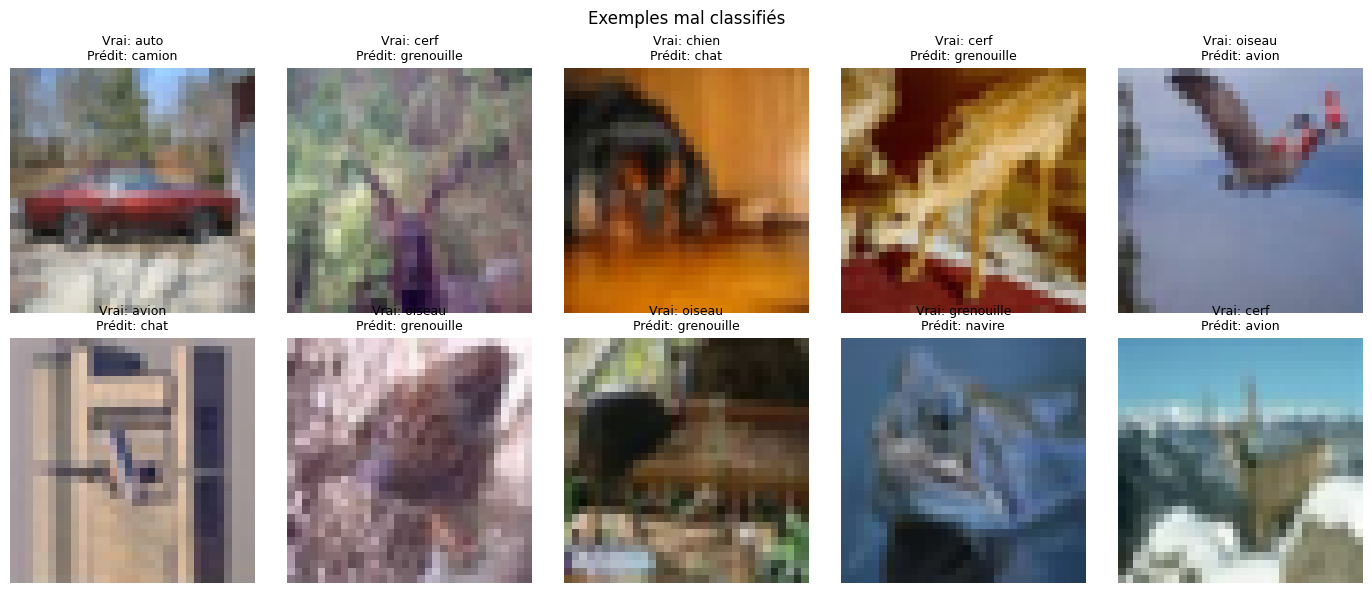

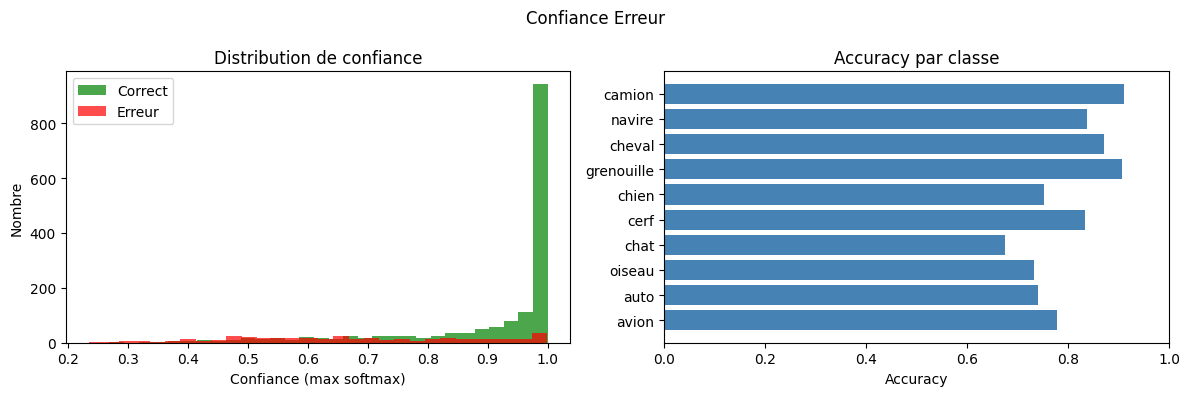

98220

In [10]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1
# - test avec 200 époques 
# - augmentation de données minimal


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)
confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_09_cnn_aug_minimal",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.01,m=0.9)",
    augmentation="flip+translation",
    regularization="BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnPlateau",
    notes="200 epochs minimal augmentation"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/200
   1/1563 [..............................] - ETA: 17:16 - loss: 2.9460 - accuracy: 0.0938

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.5865 - accuracy: 0.4201 - val_loss: 1.2860 - val_accuracy: 0.5376 - lr: 0.0100
Epoch 2/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.2136 - accuracy: 0.5710 - val_loss: 1.4117 - val_accuracy: 0.5352 - lr: 0.0100
Epoch 3/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.0644 - accuracy: 0.6248 - val_loss: 1.6505 - val_accuracy: 0.4831 - lr: 0.0100
Epoch 4/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9642 - accuracy: 0.6659 - val_loss: 1.0683 - val_accuracy: 0.6414 - lr: 0.0100
Epoch 5/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8966 - accuracy: 0.6924 - val_loss: 0.7601 - val_accuracy: 0.7365 - lr: 0.0100
Epoch 6/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8408 - accuracy: 0.7137 - val_loss: 0.7535 - val_accuracy: 0.7417 - lr: 0.0100
Epoch 7/200
1563/1563 [==============================] - 3s 2ms/

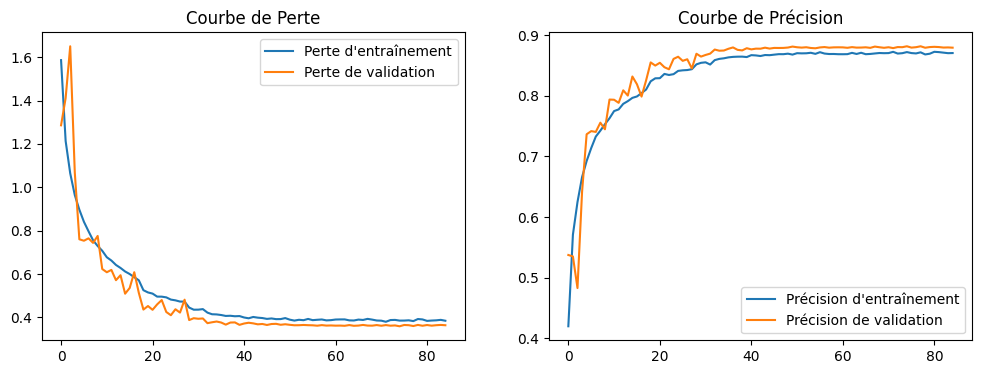

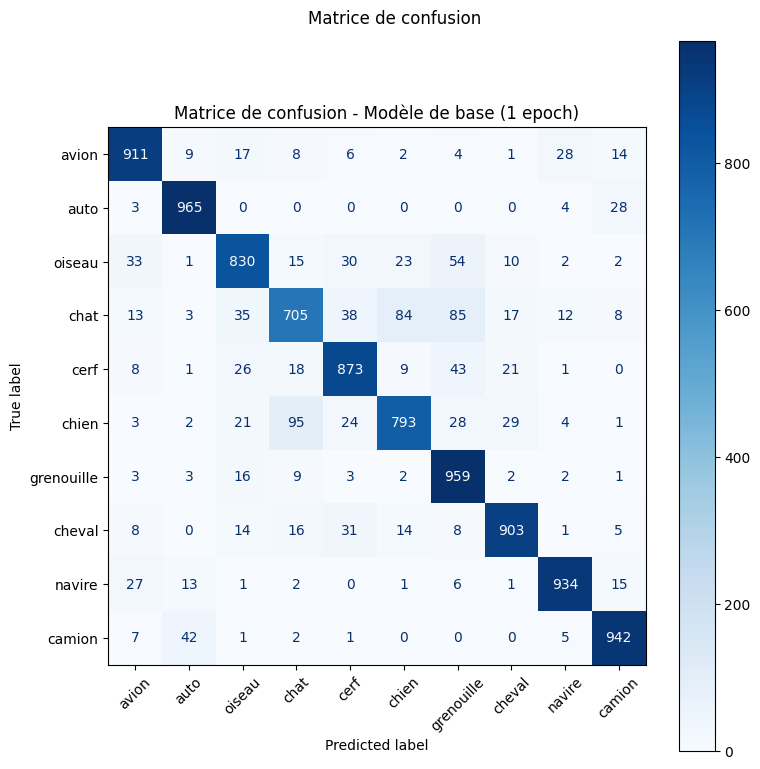

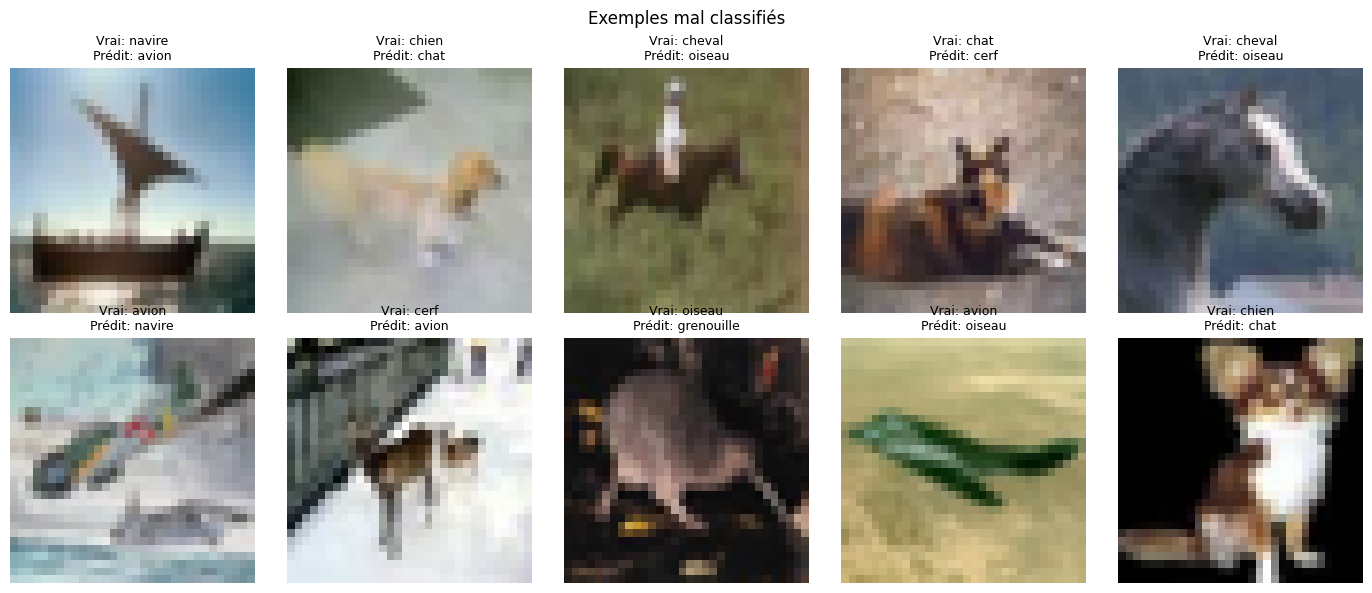

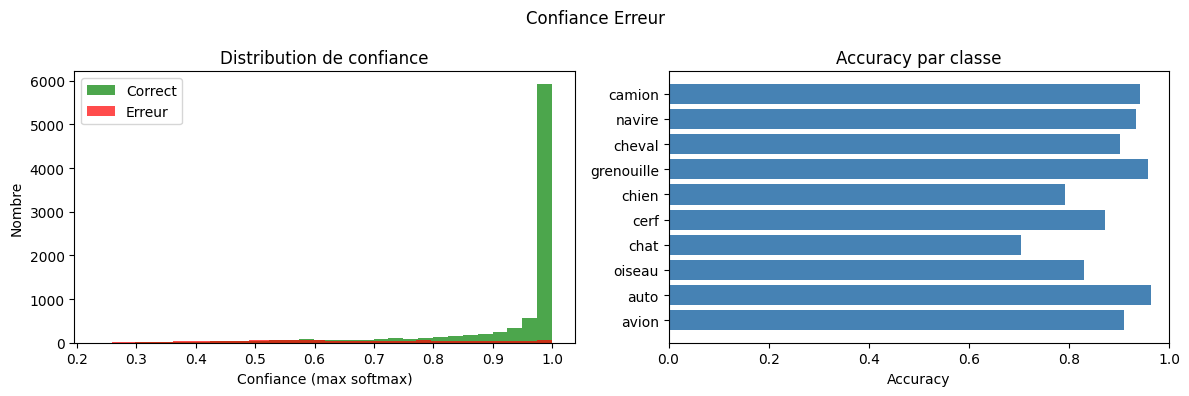

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.6691 - accuracy: 0.7773 - 116ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7773
64/64 [==============================] - 0s 501us/step


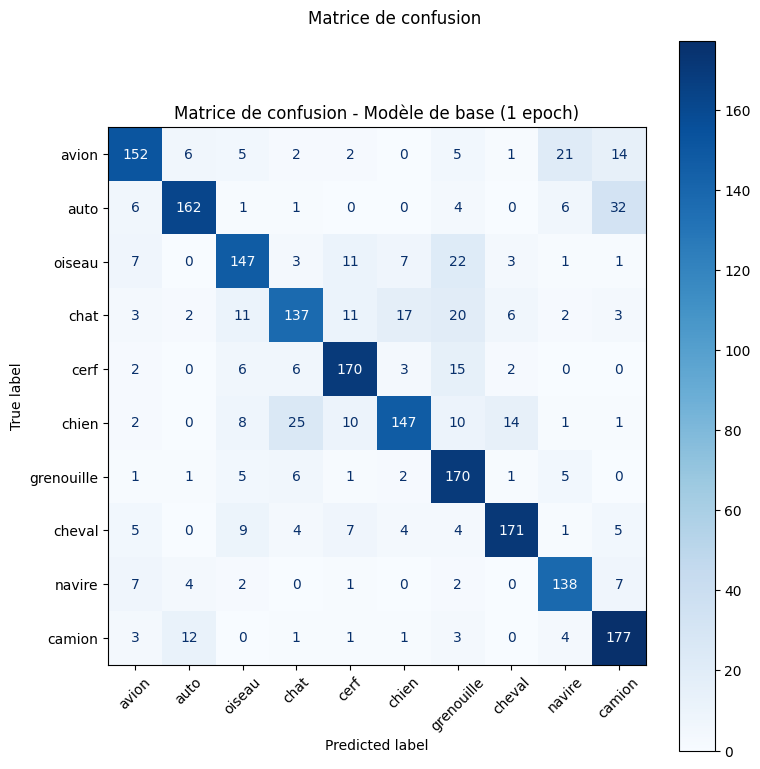

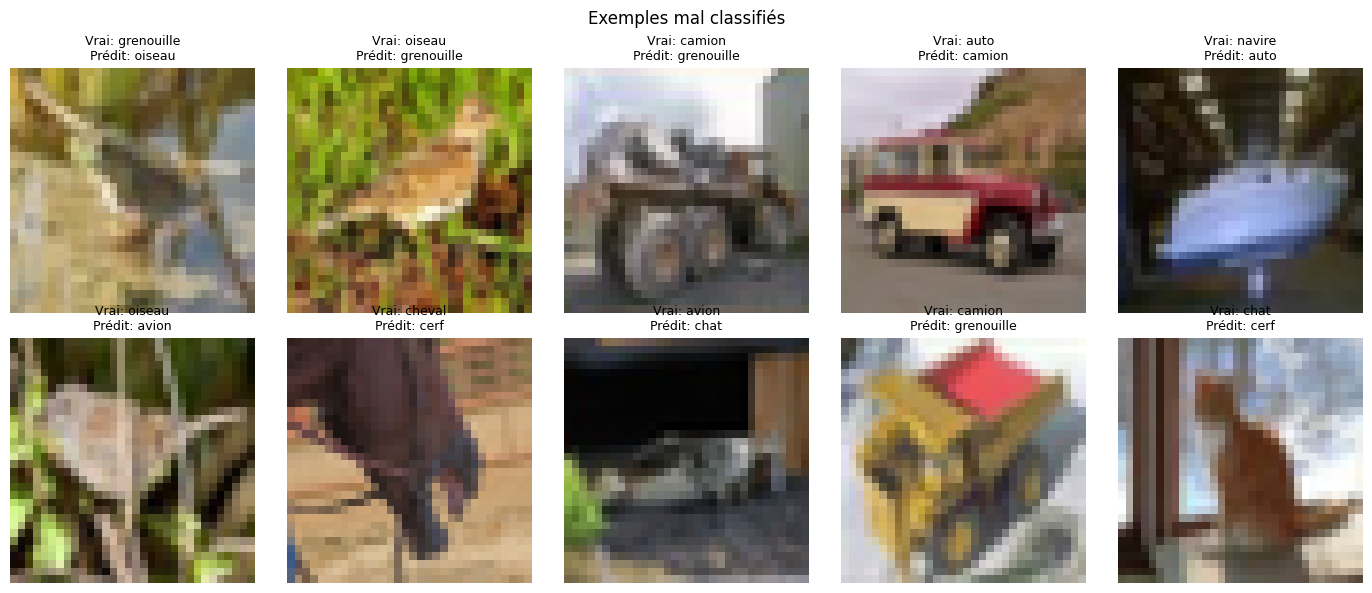

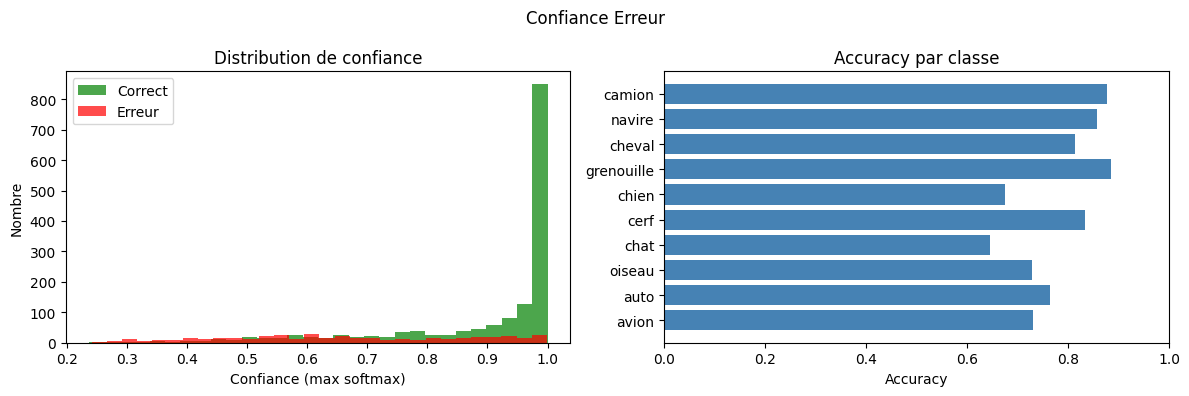

98689

In [11]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1
# - test avec 200 époques 
# - augmentation de données minimal
# - GlobalAveragePooling2D
# - dense avec 128 neurones


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(), 
    layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)
confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_10_cnn_gap_dense128_lr001",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.01,m=0.9,nesterov=True)",
    augmentation="flip+translation",
    regularization="BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnPlateau",
    notes="GAP + Dense128"
)

del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/200
  24/1563 [..............................] - ETA: 3s - loss: 2.5724 - accuracy: 0.1654   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.5845 - accuracy: 0.4237 - val_loss: 1.3679 - val_accuracy: 0.5005 - lr: 0.0200
Epoch 2/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.1856 - accuracy: 0.5784 - val_loss: 1.1723 - val_accuracy: 0.5916 - lr: 0.0200
Epoch 3/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.0265 - accuracy: 0.6393 - val_loss: 0.9724 - val_accuracy: 0.6614 - lr: 0.0200
Epoch 4/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9249 - accuracy: 0.6816 - val_loss: 0.7640 - val_accuracy: 0.7362 - lr: 0.0200
Epoch 5/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8577 - accuracy: 0.7072 - val_loss: 0.8444 - val_accuracy: 0.7168 - lr: 0.0200
Epoch 6/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8022 - accuracy: 0.7287 - val_loss: 0.6608 - val_accuracy: 0.7763 - lr: 0.0200
Epoch 7/200
1563/1563 [==============================] - 3s 2ms/

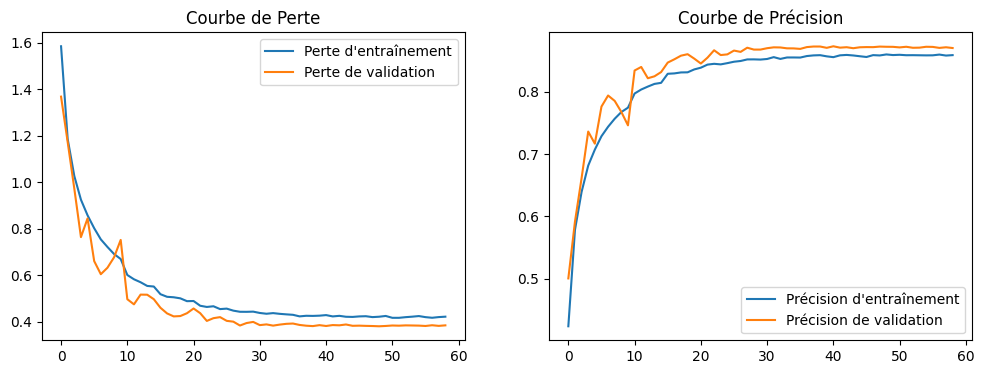

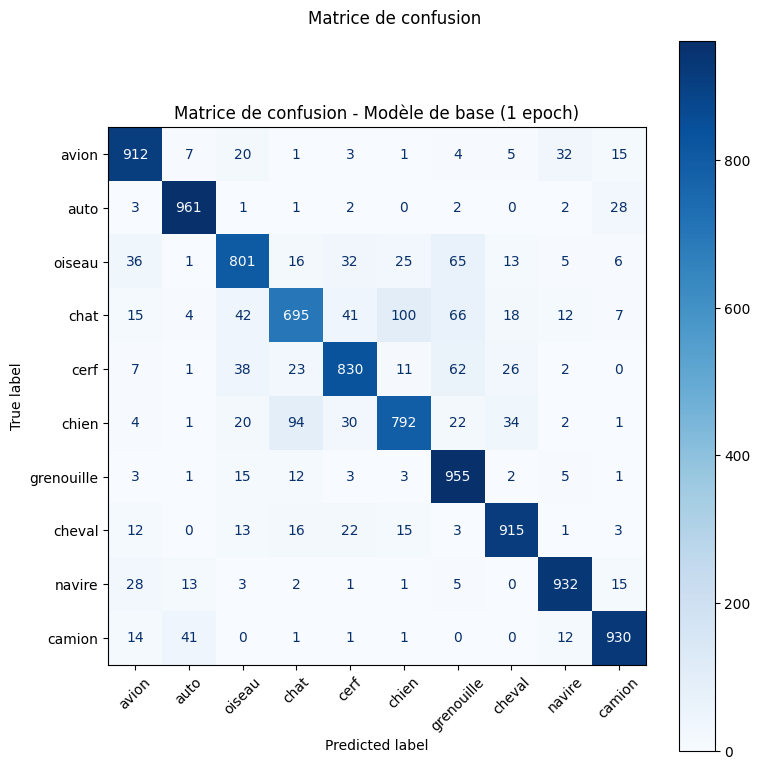

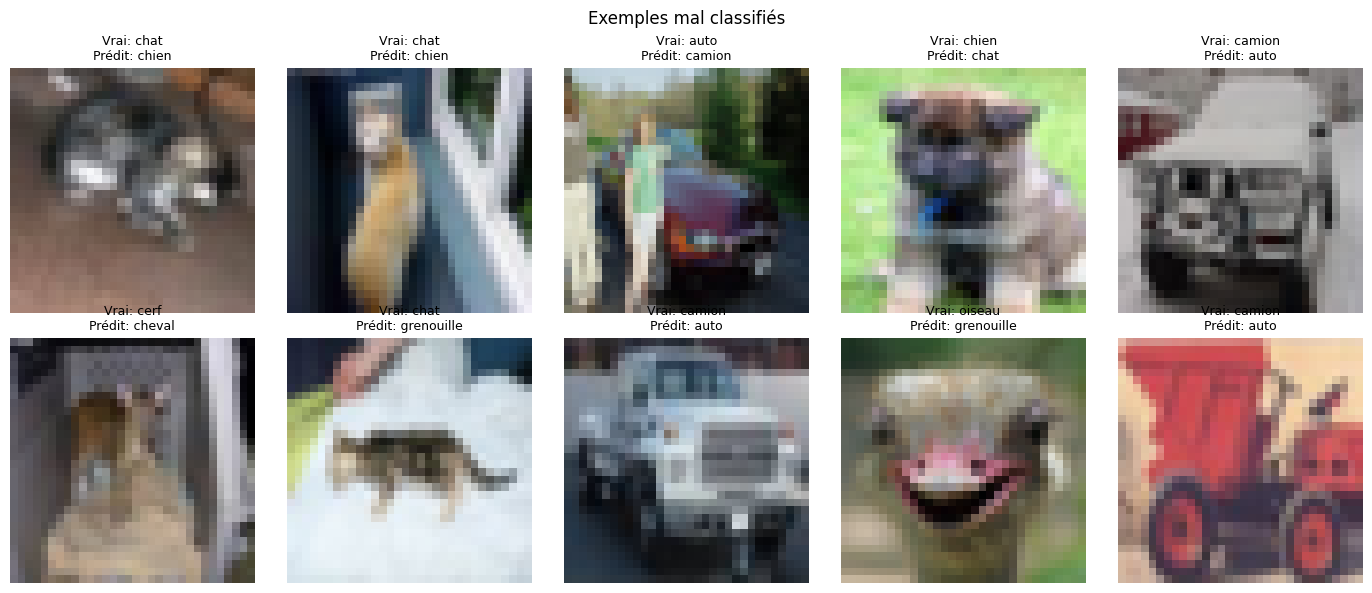

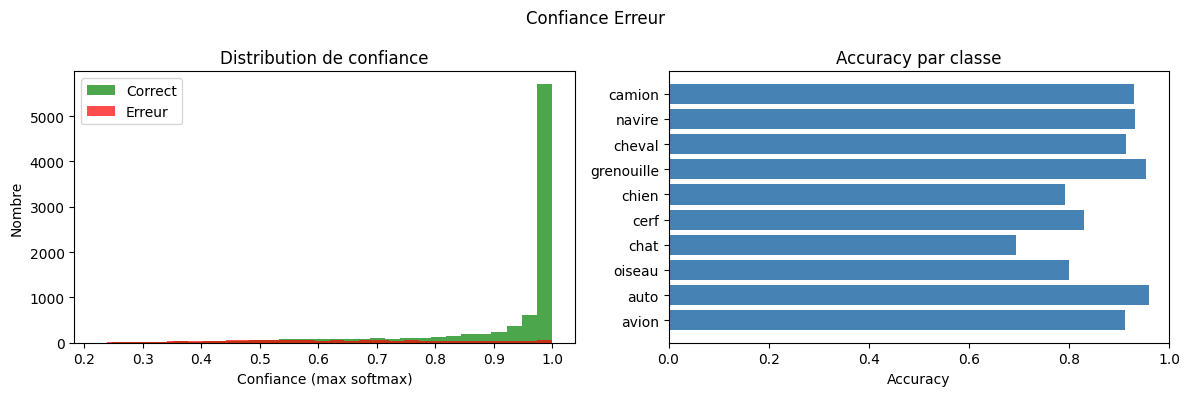

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.6924 - accuracy: 0.7724 - 129ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7724
64/64 [==============================] - 0s 503us/step


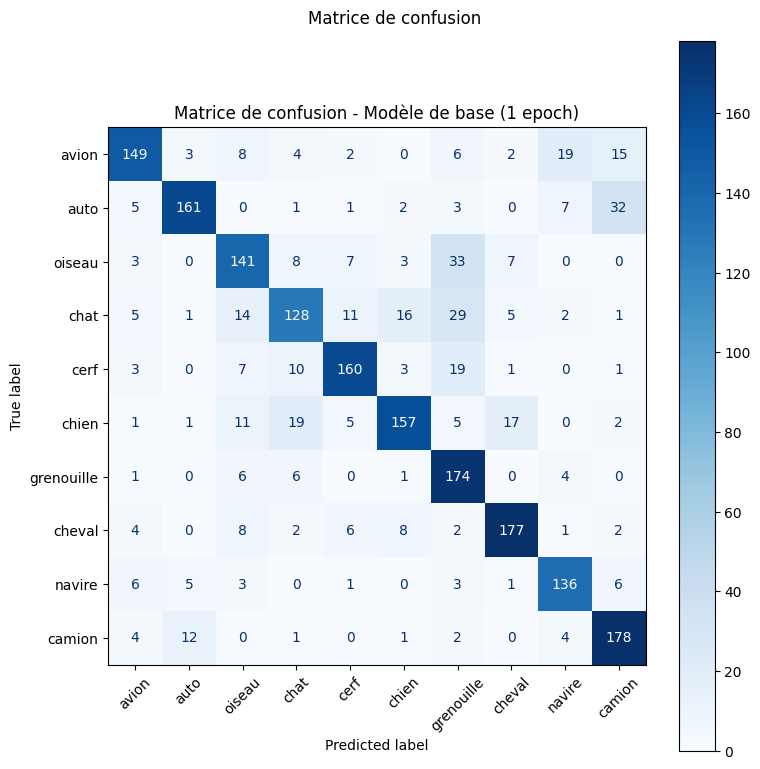

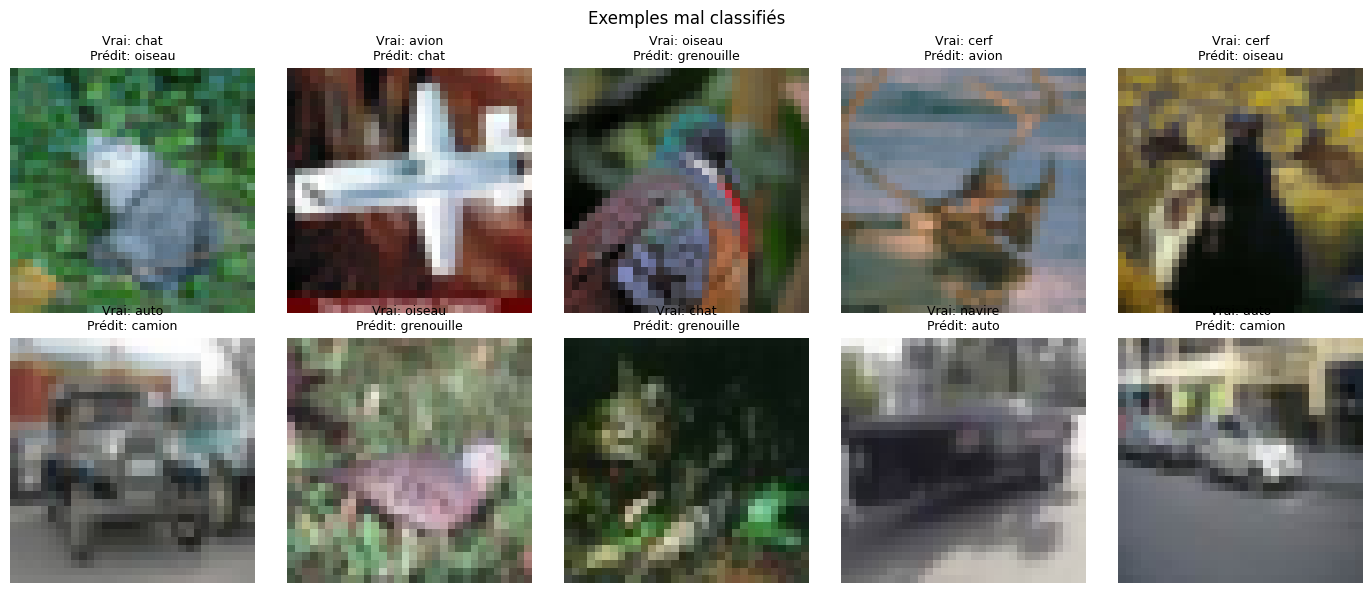

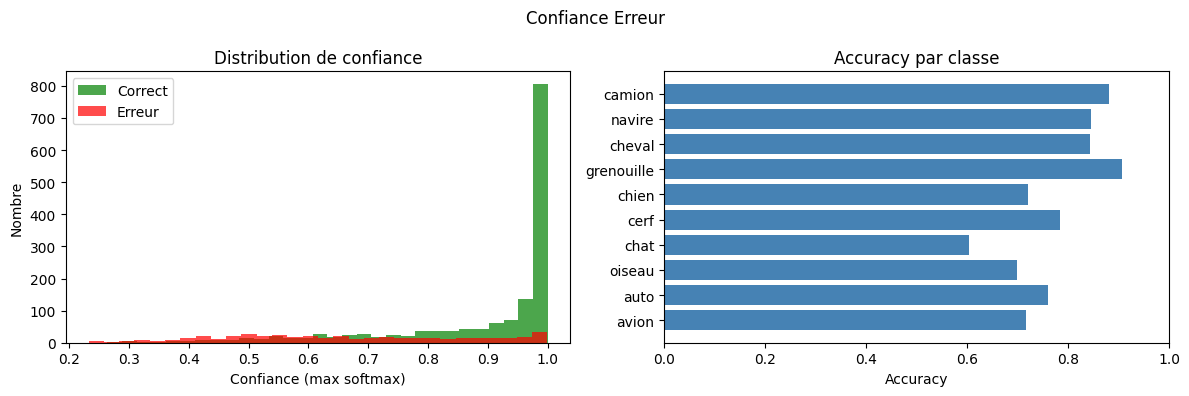

,rank,run_id,model_family,optimizer,augmentation,regularization,test_acc,ext_acc,generalization_drop_test_to_ext,best_val_acc,...,epochs_ran,final_lr,test_loss,ext_loss,best_val_loss,best_val_acc_epoch,best_val_loss_epoch,notes,final_train_loss,final_val_loss
0,1,cell_09_cnn_aug_minimal,CNN,"SGD(lr=0.01,m=0.9)",flip+translation,BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnP...,0.8932,0.801583,0.091617,0.8932,...,91,1.220703e-06,0.350813,0.631218,0.350813,81,81,200 epochs minimal augmentation,0.351861,0.353577
1,2,cell_06_cnn_deeper_l2,CNN,"SGD(lr=0.01,m=0.9)",none,BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnP...,0.8824,0.779317,0.103083,0.8847,...,62,9.765625e-06,0.430469,0.875232,0.430469,40,52,double conv blocks,0.182027,0.432188
2,3,cell_10_cnn_gap_dense128_lr001,CNN,"SGD(lr=0.01,m=0.9,nesterov=True)",flip+translation,BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnP...,0.8815,0.777338,0.104162,0.8815,...,85,6.103515e-07,0.358901,0.669138,0.358901,75,75,GAP + Dense128,0.384463,0.363669
3,4,cell_11_cnn_gap_dense128_lr002_l2_5e5,CNN,"SGD(lr=0.02,m=0.9,nesterov=True)",flip+translation,BatchNorm+Dropout+L2(5e-5)+EarlyStopping+Reduc...,0.8723,0.772390,0.099910,0.8731,...,59,4.882812e-06,0.380619,0.692408,0.380619,41,49,Final run,0.421887,0.384604
4,5,cell_07_cnn_deeper_l2_bn_act,CNN,"SGD(lr=0.01,m=0.9)",none,BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnP...,0.8793,0.770411,0.108889,0.8806,...,39,3.125000e-04,0.424872,0.836154,0.424872,37,29,Conv-BN-Activation ordering,0.203569,0.434136
5,6,cell_08_cnn_aug_full,CNN,"SGD(lr=0.01,m=0.9)",flip+rotation+zoom+translation,BatchNorm+Dropout+L2+EarlyStopping+ReduceLROnP...,0.8424,0.731321,0.111079,0.8433,...,66,9.765625e-06,0.501729,0.822430,0.501729,57,56,full geometric augmentation,0.515432,0.503518
6,7,cell_05_cnn_swish_sgd,CNN,"SGD(lr=0.01,m=0.9)",none,BatchNorm+Dropout+EarlyStopping+ReduceLROnPlateau,0.8049,0.670460,0.134440,0.8065,...,67,NaN,0.572399,0.993855,0.572399,67,57,padding same,0.658002,0.580367
7,8,cell_04_cnn_bn_dropout_relu,CNN,Adam,none,BatchNorm+Dropout+EarlyStopping,0.7836,0.639287,0.144313,0.7836,...,46,NaN,0.641048,1.070085,0.641048,36,36,ReLU blocks,0.752167,0.781953
8,9,cell_03_cnn_dropout_bn,CNN,Adam,none,BatchNorm+Dropout+EarlyStopping,0.7627,0.620485,0.142215,0.7627,...,20,NaN,0.696743,1.115039,0.696743,20,20,20 epochs,0.778042,0.696743
9,10,cell_01_transfer_vgg16_resize96,Transfer Learning,Adam,resize96,EarlyStopping+ReduceLROnPlateau+Dropout,0.7254,0.593765,0.131635,0.7271,...,50,7.812500e-06,0.809515,1.284007,0.809515,48,40,VGG16 frozen + GAP,0.657188,0.810745


Benchmark CSV: Devoir partie 2/benchmark_outputs/benchmark_runs.csv
Benchmark Markdown: Devoir partie 2/benchmark_outputs/benchmark_runs.md


99265

In [12]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1
# - test avec 200 époques 
# - augmentation de données minimal
# - GlobalAveragePooling2D
# - dense avec 128 neurones
# - learning_rate=0.02
# - kernel_regularizer=keras.regularizers.l2(5e-5)


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(), 
    layers.Dense(128, kernel_regularizer=keras.regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.02, momentum=0.9, nesterov=True),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)
confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


benchmark_tracker(
    action="log",
    run_id="cell_11_cnn_gap_dense128_lr002_l2_5e5",
    history=history_fit,
    test_acc=test_acc,
    test_loss=test_loss,
    ext_acc=ext_acc,
    ext_loss=ext_loss,
    model_family="CNN",
    optimizer="SGD(lr=0.02,m=0.9,nesterov=True)",
    augmentation="flip+translation",
    regularization="BatchNorm+Dropout+L2(5e-5)+EarlyStopping+ReduceLROnPlateau",
    notes="Final run"
)

df_bench = benchmark_tracker(action="show")
display(df_bench)

_bench_dir = os.path.join("Devoir partie 2", "benchmark_outputs")
os.makedirs(_bench_dir, exist_ok=True)
_csv_path = os.path.join(_bench_dir, "benchmark_runs.csv")
_md_path = os.path.join(_bench_dir, "benchmark_runs.md")
df_bench.to_csv(_csv_path, index=False)

_md_lines = [
    "| " + " | ".join(df_bench.columns.astype(str)) + " |",
    "| " + " | ".join(["---"] * len(df_bench.columns)) + " |",
]
for _, _row in df_bench.iterrows():
    _cells = []
    for _c in df_bench.columns:
        _v = _row[_c]
        if pd.isna(_v):
            _cells.append("")
        elif isinstance(_v, (float, np.floating)):
            _cells.append(f"{float(_v):.6g}")
        else:
            _cells.append(str(_v))
    _md_lines.append("| " + " | ".join(_cells) + " |")
with open(_md_path, "w", encoding="utf-8") as _mf:
    _mf.write("\n".join(_md_lines))

print(f"Benchmark CSV: {_csv_path}")
print(f"Benchmark Markdown: {_md_path}")

del y_proba, y_pred, history_fit, model
gc.collect()